# Aurora-as-coarse-grid-context — zero-shot analysis

**Paper experiment §3.3.3 P1.** Each model is trained on the ERA5 dataset with
precipitation dropped (19-channel context) and evaluated **zero-shot** on four
context sources for the same test window:

| eval source | context grid | lead |
|---|---|---|
| `eval_era5` | real ERA5 (precip dropped) | — (in-distribution reference) |
| `eval_aurora_lead6h`  | Aurora forecast | +6h |
| `eval_aurora_lead24h` | Aurora forecast | +24h |
| `eval_aurora_lead72h` | Aurora forecast | +72h |

**Matrix:** the configs × {europe, east_asia} × seeds {42, 123, 456}, each with
the 4 evals above. Configs cover two targets and two probabilistic heads:

- **t2m** — Gaussian head.
- **wind** — Truncated-Normal head.

> ### ⚠️ NLL / CRPS mean two different things in this notebook
> - **Training loss** (a property of the *model*): the objective the model was
>   trained with. Shown as **"trained: NLL"** / **"trained: CRPS"** and stored in
>   the `train_loss` column. Wind has both; t2m currently has only NLL-trained
>   models (a CRPS-trained t2m set can be added later and will appear automatically).
> - **Evaluation score** (a property of a *result*): NLL and CRPS computed on the
>   test set for **every** model regardless of how it was trained. Always labelled
>   **"NLL (score)"** / **"CRPS (score)"** in tables and on plot axes.
>
> So e.g. a model *trained: CRPS* still has an *NLL (score)*, and an NLL-trained
> model still has a *CRPS (score)* — that cross-comparison is the point of §7.

**Inputs.** Reads only `test_summary.json`, `test_predictions.npz`, and
`test_station_errors.npz` written by `evaluate.py` — no torch / dataset code.

In [1]:
# === Configuration =========================================================
from pathlib import Path
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "figure.autolayout": True,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 60)

# >>> EDIT THIS to point at your training-runs root (the per-region folders live under it).
RESULTS_ROOT = Path(
    "/projects/u6do/pmms2/end-to-end-forecasting/projects/tessera_downscaling/"
    ".tmp_output/training_runs_snapshot_14y_aurora_zeroshot"
)

REGIONS = ["europe", "east_asia"]
SEEDS   = [42, 123, 456]

# eval subdir -> (pretty label, lead hours). ERA5 is the in-distribution anchor (lead 0).
EVAL_SOURCES = {
    "eval_era5":          ("ERA5",       0),
    "eval_aurora_lead6h": ("Aurora +6h", 6),
    "eval_aurora_lead24h":("Aurora +24h",24),
    "eval_aurora_lead72h":("Aurora +72h",72),
}
EVAL_ORDER = [v[0] for v in EVAL_SOURCES.values()]   # categorical x-axis order
AURORA_LABELS = EVAL_ORDER[1:]

# Display names: training loss (model property) vs evaluation scores (result property).
TL = {"nll": "NLL", "crps": "CRPS"}                 # train_loss value -> label
def trained_lab(tl): return f"trained: {TL.get(tl, str(tl).upper())}"
METRIC_LABEL = {"rmse": "RMSE", "mae": "MAE", "bias": "bias",
                "correlation": "correlation",
                "crps": "CRPS (score)", "nll": "NLL (score)"}
def metlab(m): return METRIC_LABEL.get(m, m.upper())

OUT_DIR = Path("aurora_zeroshot_analysis_outputs"); OUT_DIR.mkdir(exist_ok=True)
print("RESULTS_ROOT:", RESULTS_ROOT, "\nexists:", RESULTS_ROOT.exists())

RESULTS_ROOT: /projects/u6do/pmms2/end-to-end-forecasting/projects/tessera_downscaling/.tmp_output/training_runs_snapshot_14y_aurora_zeroshot 
exists: True


## 1. Load every `test_summary.json` into one tidy table

One row per `(region, config, seed, eval_source, variable)`. The config name is
parsed into `target` / `model` / `train_loss`.

`train_loss` is the **training objective** (NLL- vs CRPS-trained). The `nll` and
`crps` columns are **evaluation scores** computed for every model.

In [2]:
# === Parse + load ==========================================================
def parse_config(name: str) -> dict:
    """config dir name -> structured factors. `train_loss` = training objective."""
    target = "t2m" if name.startswith("t2m") else "wind"
    model  = "tessera" if ("vae_lat16_concat" in name or "vae" in name) else "baseline"
    train_loss = "crps" if name.endswith("_crps") else "nll"
    head = "gaussian" if target == "t2m" else "truncated_normal"
    return {"target": target, "model": model, "train_loss": train_loss, "head": head}

# Evaluation metrics, named identically by evaluate.py for the Gaussian (t2m) and
# Truncated-Normal (wind) heads, plus the universal proper-scoring metrics.
SCALAR_METRICS = [
    "nll", "crps", "mae", "rmse", "bias", "correlation", "mean_pred_std",
    "within_1sigma", "within_2sigma", "pit_chi2_stat", "pit_chi2_pvalue",
    "p50", "p90", "p95", "p99", "n_predictions", "n_test_stations",
]
SEASONS = ["DJF", "MAM", "JJA", "SON"]

def g(d, key, default=np.nan):
    v = d.get(key, default)
    return v if v is not None else default

rows = []
for region in REGIONS:
    region_dir = RESULTS_ROOT / region
    if not region_dir.is_dir():
        continue
    for seed_dir in sorted(region_dir.glob("*_seed*")):
        m = re.match(r"(?P<config>.+)_seed(?P<seed>\d+)$", seed_dir.name)
        if not m:
            continue
        config = m.group("config"); seed = int(m.group("seed"))
        factors = parse_config(config)
        for eval_key, (eval_label, lead) in EVAL_SOURCES.items():
            summ = seed_dir / eval_key / "test_summary.json"
            present = summ.exists()
            base = dict(region=region, config=config, seed=seed,
                        eval_source=eval_key, eval_label=eval_label,
                        lead_hours=lead, present=present, **factors)
            if not present:
                rows.append({**base, "variable": factors["target"]})
                continue
            d = json.loads(summ.read_text())
            tvars = d.get("target_variables", [factors["target"]])
            for var in tvars:
                row = {**base, "variable": var,
                       "checkpoint_epoch": g(d, "checkpoint_epoch"),
                       "best_val_loss": g(d, "best_val_loss")}
                for met in SCALAR_METRICS:
                    row[met] = g(d, f"{var}_{met}")
                seas = d.get(f"{var}_seasonal_mae", {}) or {}
                for s in SEASONS:
                    row[f"seasonal_mae_{s}"] = g(seas, s)
                rows.append(row)

df = pd.DataFrame(rows)
df["eval_label"] = pd.Categorical(df["eval_label"], categories=EVAL_ORDER, ordered=True)
df["model"] = pd.Categorical(df["model"], categories=["baseline", "tessera"], ordered=True)
df["train_loss"] = pd.Categorical(df["train_loss"], categories=["nll", "crps"], ordered=True)
print(f"Loaded {df['present'].sum()} eval cells "
      f"({df[df.present].drop_duplicates(['region','config','seed','eval_source']).shape[0]} unique).")
df.head()

Loaded 192 eval cells (192 unique).


,region,config,seed,eval_source,eval_label,lead_hours,present,target,model,train_loss,head,variable,checkpoint_epoch,best_val_loss,nll,crps,mae,rmse,bias,correlation,mean_pred_std,within_1sigma,within_2sigma,pit_chi2_stat,pit_chi2_pvalue,p50,p90,p95,p99,n_predictions,n_test_stations,seasonal_mae_DJF,seasonal_mae_MAM,seasonal_mae_JJA,seasonal_mae_SON
0,europe,t2m_snap_bilinear_baseline_wd_crps,123,eval_era5,ERA5,0,True,t2m,baseline,crps,gaussian,t2m,6,0.829016,1.803275,0.858135,1.188935,1.705907,0.086811,0.982901,1.391879,68.002792,93.097265,7053.092324,0.0,0.828507,2.664680,3.539077,5.712314,1195048,898,1.214417,1.178375,1.228641,1.131357
1,europe,t2m_snap_bilinear_baseline_wd_crps,123,eval_aurora_lead6h,Aurora +6h,6,True,t2m,baseline,crps,gaussian,t2m,6,0.829016,1.856287,0.889564,1.233856,1.748866,0.056798,0.981969,1.392632,65.818444,92.207426,11682.068081,0.0,0.875784,2.742189,3.607465,5.746867,1195048,898,1.252311,1.223146,1.279797,1.178257
2,europe,t2m_snap_bilinear_baseline_wd_crps,123,eval_aurora_lead24h,Aurora +24h,24,True,t2m,baseline,crps,gaussian,t2m,6,0.829016,1.939157,0.932183,1.288335,1.812408,0.188699,0.980825,1.377121,63.046924,90.493520,40571.265787,0.0,0.922979,2.858934,3.746057,5.882905,1195048,898,1.318961,1.285645,1.335652,1.209244
3,europe,t2m_snap_bilinear_baseline_wd_crps,123,eval_aurora_lead72h,Aurora +72h,72,True,t2m,baseline,crps,gaussian,t2m,6,0.829016,2.330875,1.117891,1.522735,2.069926,0.034608,0.974770,1.372408,53.906287,83.773120,174729.881056,0.0,1.146486,3.305349,4.223502,6.412300,1195048,898,1.574916,1.498193,1.579849,1.431833
4,europe,t2m_snap_bilinear_baseline_wd_crps,42,eval_era5,ERA5,0,True,t2m,baseline,crps,gaussian,t2m,7,0.827842,1.839085,0.858647,1.179941,1.711696,0.182144,0.982935,1.239691,64.136169,90.554020,37028.799811,0.0,0.808244,2.665453,3.568293,5.802452,1195048,898,1.209501,1.176223,1.214453,1.115828


### 1a. Completeness — which expected cells are present?

Missing cells (unfinished or failed jobs) are listed so nothing silently drops
out of the aggregates below.

In [3]:
# === Completeness ==========================================================
all_configs = sorted(df["config"].unique())
expected = len(all_configs) * len(REGIONS) * len(SEEDS) * len(EVAL_SOURCES)
print(f"Configs found: {len(all_configs)}  ->  expected {expected} eval cells; "
      f"present {int(df['present'].sum())}.\n")

comp = (df.assign(ok=df["present"].astype(int))
          .pivot_table(index=["region", "config", "seed"], columns="eval_label",
                       values="ok", aggfunc="max", observed=False)
          .reindex(columns=EVAL_ORDER))
missing = comp[(comp.fillna(0) == 0).any(axis=1)]
if len(missing):
    print("Incomplete (missing evals shown as 0/NaN):")
    display(missing)
else:
    print("All expected cells present. \u2713")
D = df[df["present"]].copy()   # analyses below use present rows only

Configs found: 8  ->  expected 192 eval cells; present 192.

All expected cells present. ✓


## 2. Headline metrics (seed mean ± std)

Per `(region, target, model, train_loss)`, each metric for every context source
side by side. **All four metrics below are evaluation scores** — including NLL
and CRPS. Rows are grouped by the model's **training loss** (`train_loss`).

In [4]:
# === Aggregation helpers ===================================================
def agg(frame, metric, by=("region","target","model","train_loss","eval_label")):
    by = list(by)
    return (frame.groupby(by, observed=True)[metric]
                 .agg(mean="mean", std="std", n="count").reset_index())

def fmt_ms(m, s):
    if pd.isna(m): return ""
    return f"{m:.3f}\u00b1{s:.3f}" if pd.notna(s) else f"{m:.3f}"

def pivot_mean_std(frame, metric, target):
    sub = frame[frame.target == target]
    a = agg(sub, metric)
    a["cell"] = [fmt_ms(m, s) for m, s in zip(a["mean"], a["std"])]
    return a.pivot_table(index=["region","model","train_loss"], columns="eval_label",
                         values="cell", aggfunc="first", observed=False).reindex(columns=EVAL_ORDER)

HEADLINE_METRICS = ["rmse", "mae", "crps", "nll"]   # all evaluation scores
for target in ["t2m", "wind"]:
    if (D.target == target).sum() == 0:
        continue
    print(f"\n{'='*74}\n{target.upper()}  (rows grouped by training loss; all columns are eval scores)\n{'='*74}")
    for metric in HEADLINE_METRICS:
        print(f"\n{target.upper()} — {metlab(metric)} [evaluation metric], seed mean\u00b1std:")
        display(pivot_mean_std(D, metric, target))


T2M  (rows grouped by training loss; all columns are eval scores)

T2M — RMSE [evaluation metric], seed mean±std:


eval_label                            ERA5   Aurora +6h  Aurora +24h  Aurora +72h
region    model    train_loss                                                    
east_asia baseline nll         1.839±0.025  1.875±0.016  1.952±0.005  2.167±0.015
                   crps        1.915±0.071  1.936±0.054  2.000±0.040  2.195±0.009
          tessera  nll         1.543±0.002  1.571±0.009  1.658±0.014  1.892±0.026
                   crps        1.540±0.003  1.569±0.004  1.652±0.010  1.890±0.020
europe    baseline nll         1.680±0.010  1.724±0.010  1.789±0.012  2.050±0.008
                   crps        1.710±0.003  1.753±0.005  1.815±0.003  2.072±0.008
          tessera  nll         1.597±0.013  1.640±0.014  1.709±0.015  1.993±0.014
                   crps        1.569±0.004  1.611±0.004  1.683±0.002  1.974±0.007


T2M — MAE [evaluation metric], seed mean±std:


eval_label                            ERA5   Aurora +6h  Aurora +24h  Aurora +72h
region    model    train_loss                                                    
east_asia baseline nll         1.340±0.023  1.376±0.017  1.443±0.011  1.623±0.024
                   crps        1.374±0.055  1.398±0.039  1.451±0.025  1.618±0.007
          tessera  nll         1.106±0.006  1.136±0.011  1.210±0.016  1.409±0.026
                   crps        1.101±0.006  1.131±0.004  1.201±0.005  1.404±0.015
europe    baseline nll         1.174±0.010  1.219±0.009  1.277±0.011  1.509±0.007
                   crps        1.183±0.005  1.228±0.006  1.284±0.004  1.520±0.009
          tessera  nll         1.111±0.011  1.156±0.012  1.214±0.012  1.465±0.013
                   crps        1.087±0.000  1.130±0.002  1.193±0.001  1.445±0.006


T2M — CRPS (score) [evaluation metric], seed mean±std:


...

eval_label                            ERA5   Aurora +6h  Aurora +24h  Aurora +72h
region    model    train_loss                                                    
east_asia baseline nll         1.264±0.004  1.264±0.002  1.274±0.005  1.310±0.014
                   crps        1.243±0.003  1.244±0.001  1.253±0.003  1.289±0.010
          tessera  nll         1.158±0.020  1.155±0.019  1.170±0.019  1.221±0.021
                   crps        1.172±0.012  1.167±0.012  1.182±0.013  1.234±0.013
europe    baseline nll         1.296±0.023  1.288±0.023  1.301±0.023  1.381±0.018
                   crps        1.282±0.003  1.274±0.003  1.287±0.003  1.367±0.003
          tessera  nll         1.222±0.007  1.207±0.005  1.222±0.005  1.313±0.006
                   crps        1.196±0.014  1.185±0.011  1.200±0.010  1.296±0.011


WIND — CRPS (score) [evaluation metric], seed mean±std:


eval_label                            ERA5   Aurora +6h  Aurora +24h  Aurora +72h
region    model    train_loss                                                    
east_asia baseline nll         0.902±0.012  0.903±0.014  0.910±0.012  0.936±0.005
                   crps        0.897±0.003  0.898±0.004  0.905±0.004  0.933±0.007
          tessera  nll         0.815±0.007  0.814±0.006  0.825±0.006  0.863±0.007
                   crps        0.823±0.004  0.820±0.004  0.831±0.004  0.870±0.004
europe    baseline nll         0.922±0.013  0.918±0.013  0.926±0.012  0.986±0.008
                   crps        0.920±0.008  0.917±0.008  0.925±0.008  0.987±0.011
          tessera  nll         0.862±0.001  0.855±0.003  0.865±0.002  0.932±0.001
                   crps        0.853±0.003  0.848±0.000  0.859±0.001  0.932±0.002


WIND — NLL (score) [evaluation metric], seed mean±std:


eval_label                            ERA5   Aurora +6h  Aurora +24h  Aurora +72h
region    model    train_loss                                                    
east_asia baseline nll         1.821±0.018  1.823±0.019  1.831±0.017  1.864±0.009
                   crps        1.867±0.022  1.870±0.022  1.878±0.024  1.920±0.035
          tessera  nll         1.680±0.005  1.681±0.005  1.695±0.005  1.745±0.008
                   crps        1.694±0.006  1.693±0.006  1.706±0.005  1.758±0.004
europe    baseline nll         1.752±0.006  1.748±0.006  1.758±0.005  1.833±0.011
                   crps        1.787±0.049  1.783±0.049  1.796±0.051  1.889±0.072
          tessera  nll         1.698±0.002  1.690±0.003  1.703±0.004  1.788±0.006
                   crps        1.715±0.008  1.712±0.012  1.728±0.013  1.838±0.020

## 3. Skill degradation: ERA5 → Aurora context vs lead time

The signature figure. x-axis = context source (ERA5 anchor, then Aurora at
+6/+24/+72h); lines = `tessera` vs `baseline`; band = ±1 std across seeds. A
rising curve = skill lost to the forecast-context shift; the gap between the
lines = TESSERA's contribution. Panel rows are the **training loss**.

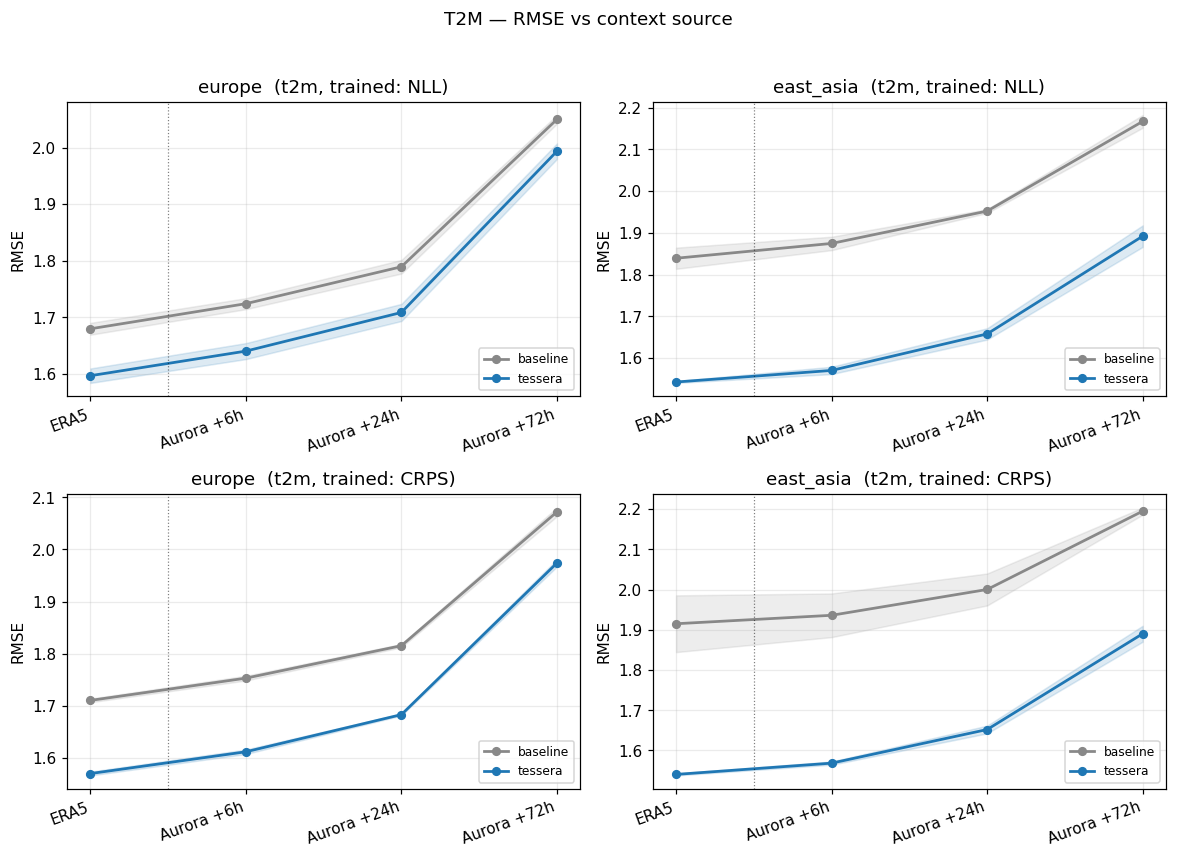

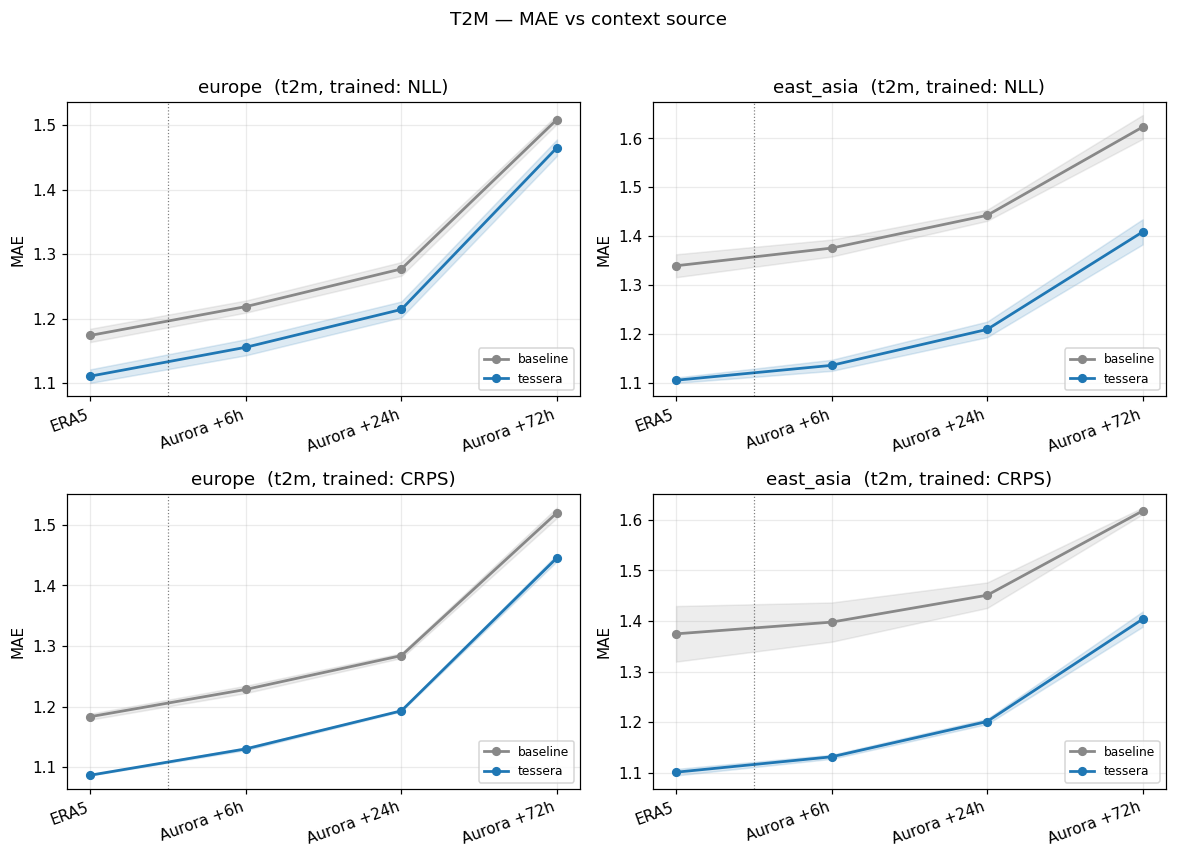

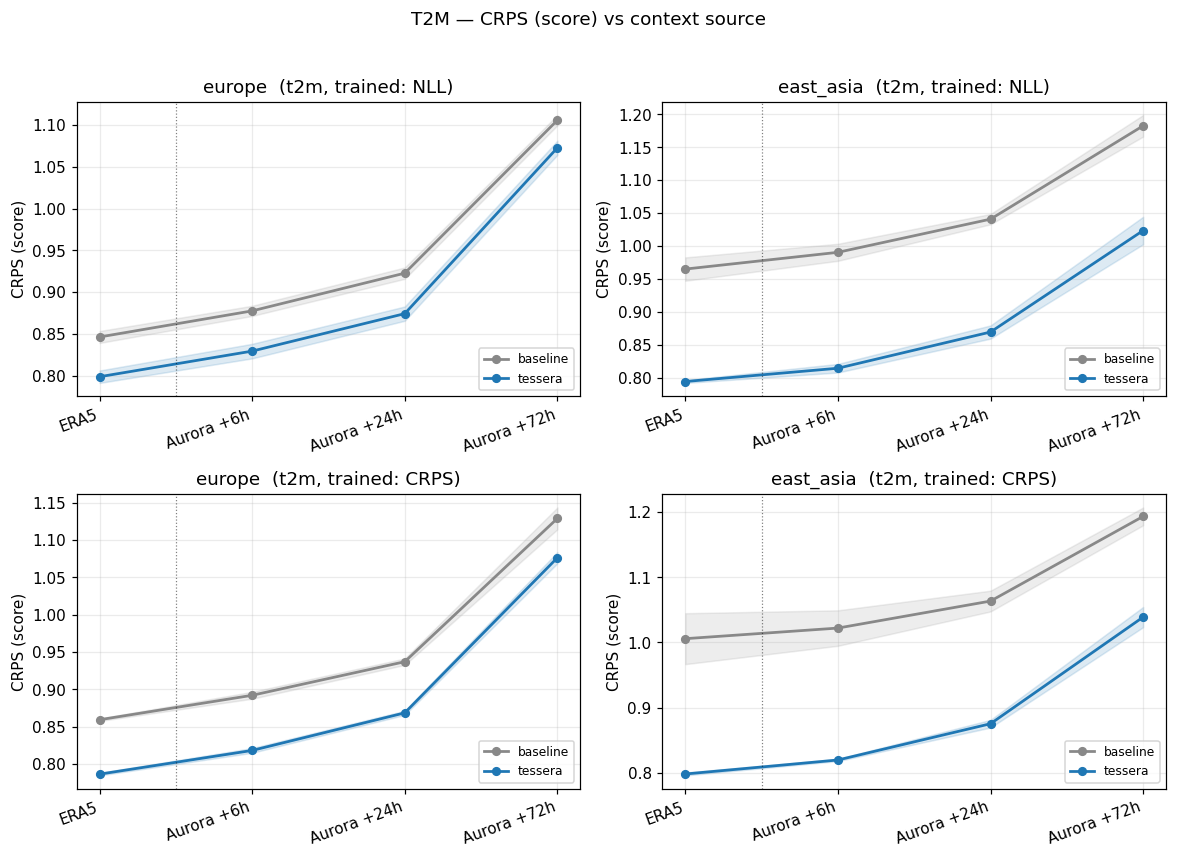

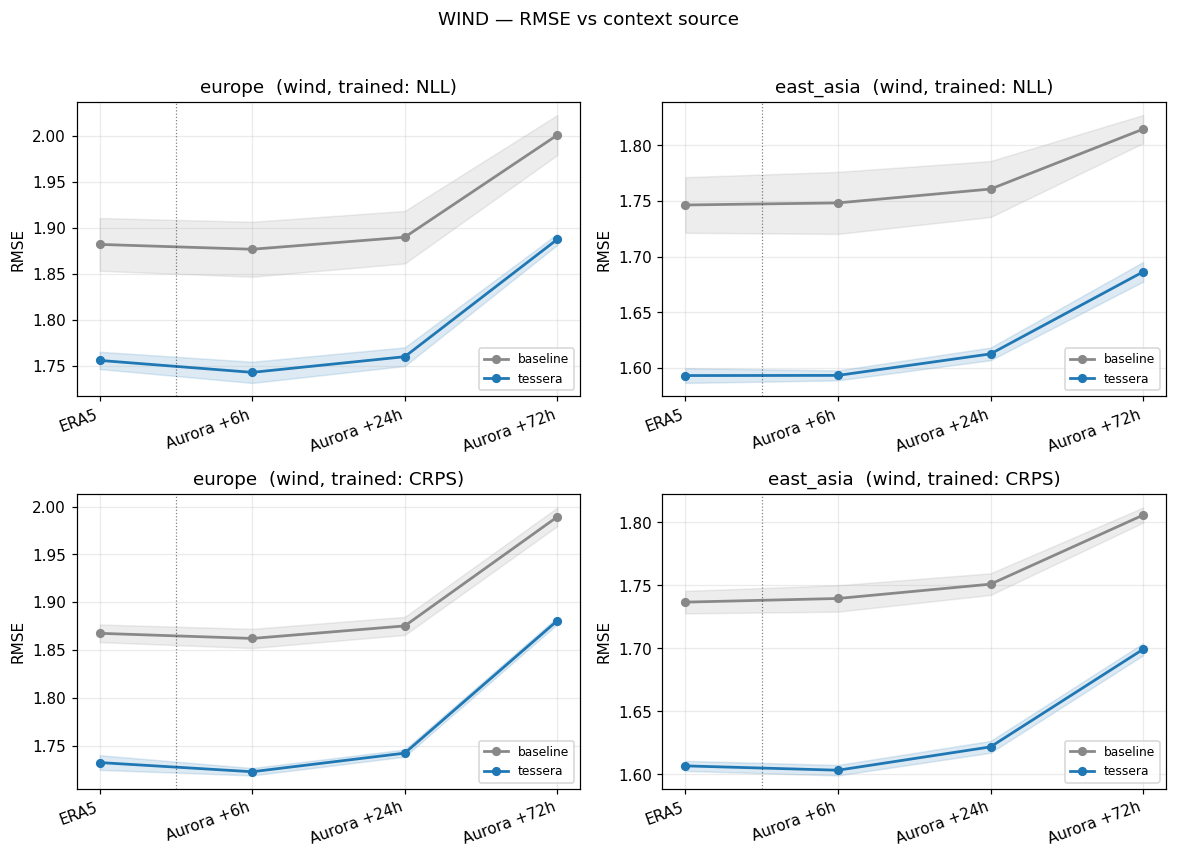

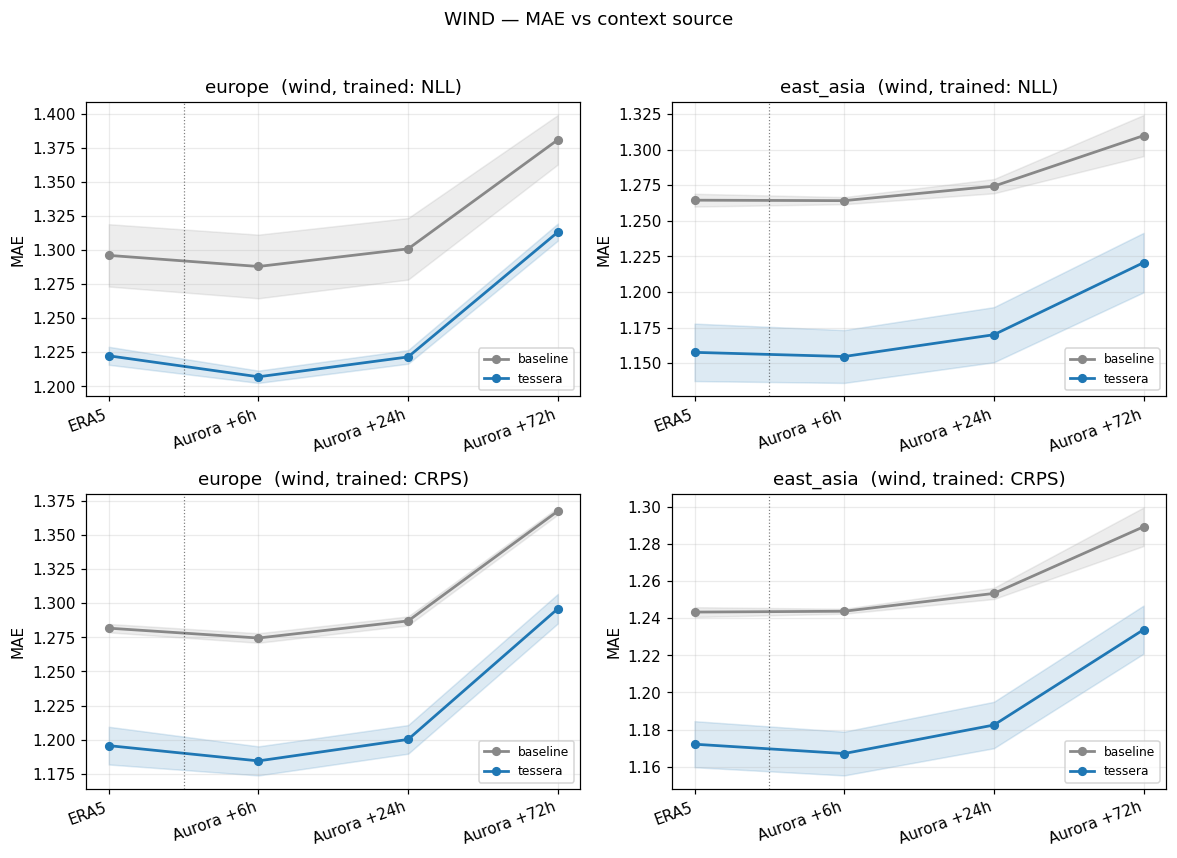

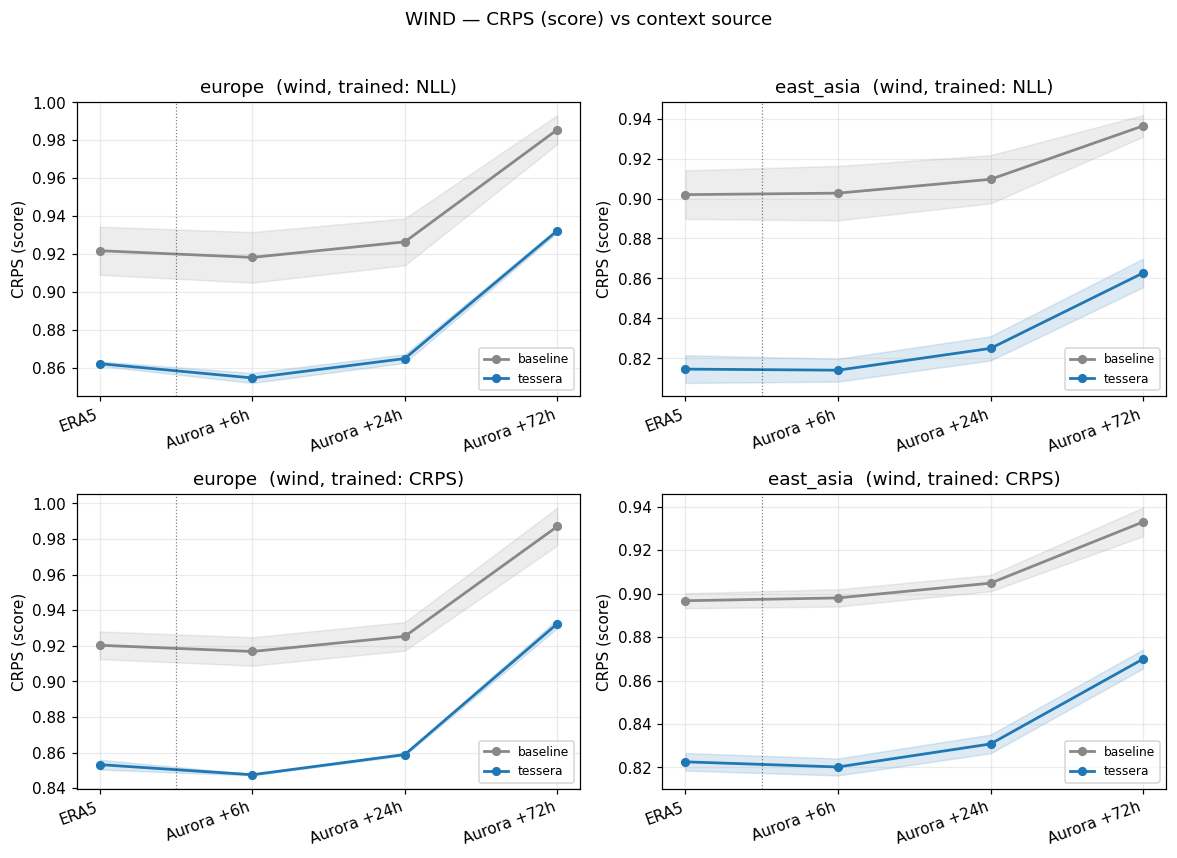

In [5]:
# === Degradation-vs-lead plots =============================================
def plot_metric_vs_lead(frame, target, metric):
    sub = frame[frame.target == target]
    if sub.empty:
        print(f"(no {target} data)"); return
    tlosses = [t for t in ["nll","crps"] if t in set(sub["train_loss"])]
    ncol = len(REGIONS); nrow = len(tlosses)
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4*ncol, 3.8*nrow), squeeze=False)
    x = np.arange(len(EVAL_ORDER))
    colors = {"baseline": "#888888", "tessera": "#1f77b4"}
    for ri, tl in enumerate(tlosses):
        for ci, region in enumerate(REGIONS):
            ax = axes[ri][ci]
            cell = sub[(sub.region == region) & (sub.train_loss == tl)]
            for model in ["baseline", "tessera"]:
                a = agg(cell[cell.model == model], metric).set_index("eval_label").reindex(EVAL_ORDER)
                if a["mean"].notna().sum() == 0:
                    continue
                ax.plot(x, a["mean"].values, "-o", color=colors[model], label=model, lw=1.8, ms=5)
                lo = a["mean"].values - a["std"].fillna(0).values
                hi = a["mean"].values + a["std"].fillna(0).values
                ax.fill_between(x, lo, hi, color=colors[model], alpha=0.15)
            ax.axvline(0.5, color="k", ls=":", lw=0.8, alpha=0.5)  # ERA5 | Aurora divider
            ax.set_xticks(x); ax.set_xticklabels(EVAL_ORDER, rotation=20, ha="right")
            ax.set_title(f"{region}  ({target}, {trained_lab(tl)})")
            ax.set_ylabel(metlab(metric)); ax.legend(fontsize=8)
    fig.suptitle(f"{target.upper()} — {metlab(metric)} vs context source", y=1.02, fontsize=12)
    fig.savefig(OUT_DIR / f"degradation_{target}_{metric}.png", bbox_inches="tight")
    plt.show()

for target in ["t2m", "wind"]:
    for metric in ["rmse", "mae", "crps"]:
        plot_metric_vs_lead(D, target, metric)

## 4. Zero-shot degradation, quantified

For each model the **% increase** in the metric relative to the ERA5 anchor when
the context is an Aurora forecast at each lead — the headline "cost of using a
forecast as context". Reported for RMSE, MAE, and the CRPS score.

In [6]:
# === % degradation vs ERA5 anchor ==========================================
def degradation_table(frame, metric):
    recs = []
    keys = ["region","target","model","train_loss"]
    means = agg(frame, metric).pivot_table(index=keys, columns="eval_label",
              values="mean", observed=False).reindex(columns=EVAL_ORDER)
    for idx, r in means.iterrows():
        base = r.get("ERA5", np.nan)
        rec = dict(zip(keys, idx)); rec["ERA5"] = base
        for lab in AURORA_LABELS:
            v = r.get(lab, np.nan)
            rec[f"{lab} (\u0394%)"] = (v - base) / base * 100 if (pd.notna(v) and base) else np.nan
        recs.append(rec)
    return pd.DataFrame(recs)

for metric in ["rmse", "mae", "crps"]:
    print(f"\n{'='*74}\n{metlab(metric)} — % increase vs ERA5 context\n{'='*74}")
    t = degradation_table(D, metric)
    fmt = {c: "{:+.1f}%".format for c in t.columns if "\u0394%" in c}
    fmt["ERA5"] = "{:.3f}".format
    display(t.style.format(fmt).hide(axis="index"))


RMSE — % increase vs ERA5 context


region,target,model,train_loss,ERA5,Aurora +6h (Δ%),Aurora +24h (Δ%),Aurora +72h (Δ%)
east_asia,t2m,baseline,nll,1.839,+1.9%,+6.1%,+17.8%
east_asia,t2m,baseline,crps,1.915,+1.1%,+4.4%,+14.6%
east_asia,t2m,tessera,nll,1.543,+1.8%,+7.5%,+22.6%
east_asia,t2m,tessera,crps,1.540,+1.8%,+7.2%,+22.7%
east_asia,wind,baseline,nll,1.746,+0.1%,+0.8%,+3.9%
east_asia,wind,baseline,crps,1.737,+0.2%,+0.8%,+4.0%
east_asia,wind,tessera,nll,1.593,+0.0%,+1.2%,+5.9%
east_asia,wind,tessera,crps,1.607,-0.2%,+0.9%,+5.8%
europe,t2m,baseline,nll,1.680,+2.6%,+6.5%,+22.0%
europe,t2m,baseline,crps,1.710,+2.5%,+6.2%,+21.2%



MAE — % increase vs ERA5 context


region,target,model,train_loss,ERA5,Aurora +6h (Δ%),Aurora +24h (Δ%),Aurora +72h (Δ%)
east_asia,t2m,baseline,nll,1.340,+2.7%,+7.7%,+21.2%
east_asia,t2m,baseline,crps,1.374,+1.7%,+5.6%,+17.7%
east_asia,t2m,tessera,nll,1.106,+2.7%,+9.4%,+27.4%
east_asia,t2m,tessera,crps,1.101,+2.8%,+9.1%,+27.5%
east_asia,wind,baseline,nll,1.264,-0.0%,+0.8%,+3.6%
east_asia,wind,baseline,crps,1.243,+0.0%,+0.8%,+3.7%
east_asia,wind,tessera,nll,1.158,-0.3%,+1.1%,+5.4%
east_asia,wind,tessera,crps,1.172,-0.4%,+0.9%,+5.3%
europe,t2m,baseline,nll,1.174,+3.8%,+8.8%,+28.5%
europe,t2m,baseline,crps,1.183,+3.8%,+8.5%,+28.4%



CRPS (score) — % increase vs ERA5 context


region,target,model,train_loss,ERA5,Aurora +6h (Δ%),Aurora +24h (Δ%),Aurora +72h (Δ%)
east_asia,t2m,baseline,nll,0.965,+2.6%,+7.8%,+22.5%
east_asia,t2m,baseline,crps,1.006,+1.6%,+5.7%,+18.7%
east_asia,t2m,tessera,nll,0.795,+2.5%,+9.4%,+28.8%
east_asia,t2m,tessera,crps,0.798,+2.7%,+9.7%,+30.2%
east_asia,wind,baseline,nll,0.902,+0.1%,+0.9%,+3.8%
east_asia,wind,baseline,crps,0.897,+0.1%,+0.9%,+4.1%
east_asia,wind,tessera,nll,0.815,-0.1%,+1.3%,+5.9%
east_asia,wind,tessera,crps,0.823,-0.3%,+1.0%,+5.8%
europe,t2m,baseline,nll,0.846,+3.7%,+9.0%,+30.6%
europe,t2m,baseline,crps,0.859,+3.8%,+9.0%,+31.4%


## 5. TESSERA uplift and its robustness to the context shift

Per seed we pair `tessera` against `baseline` (same region/target/training-loss/
eval) and take `baseline − tessera` (positive = TESSERA better). We then ask
whether that uplift **holds up** as the context degrades.

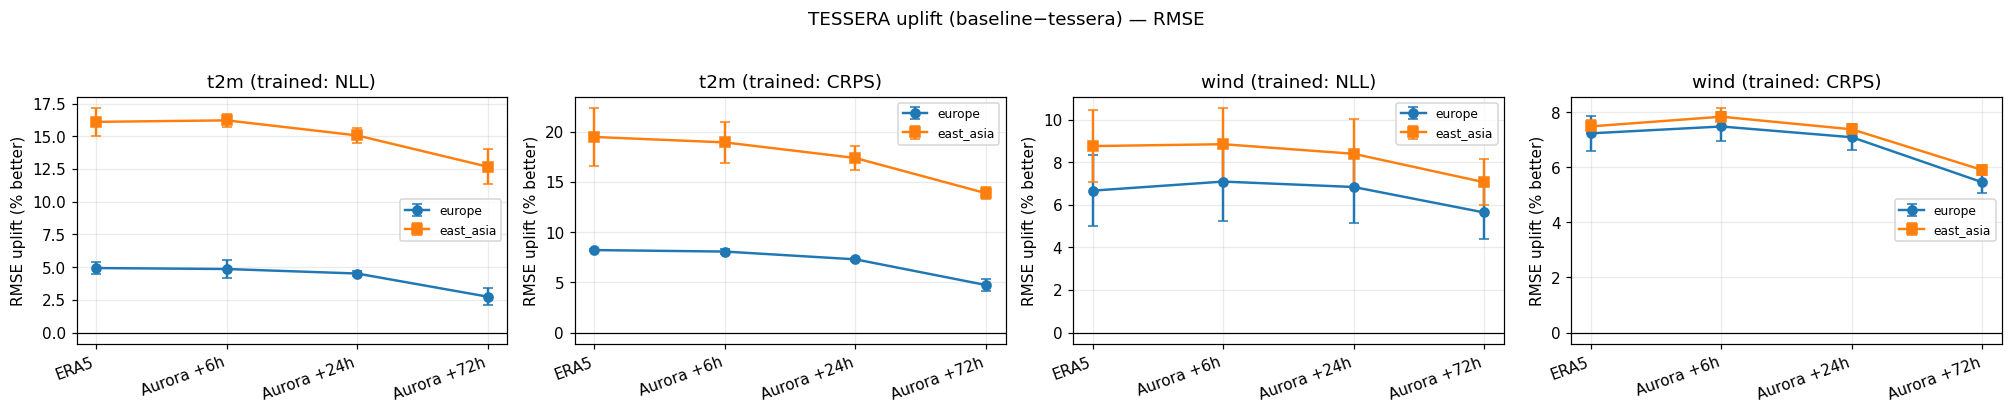

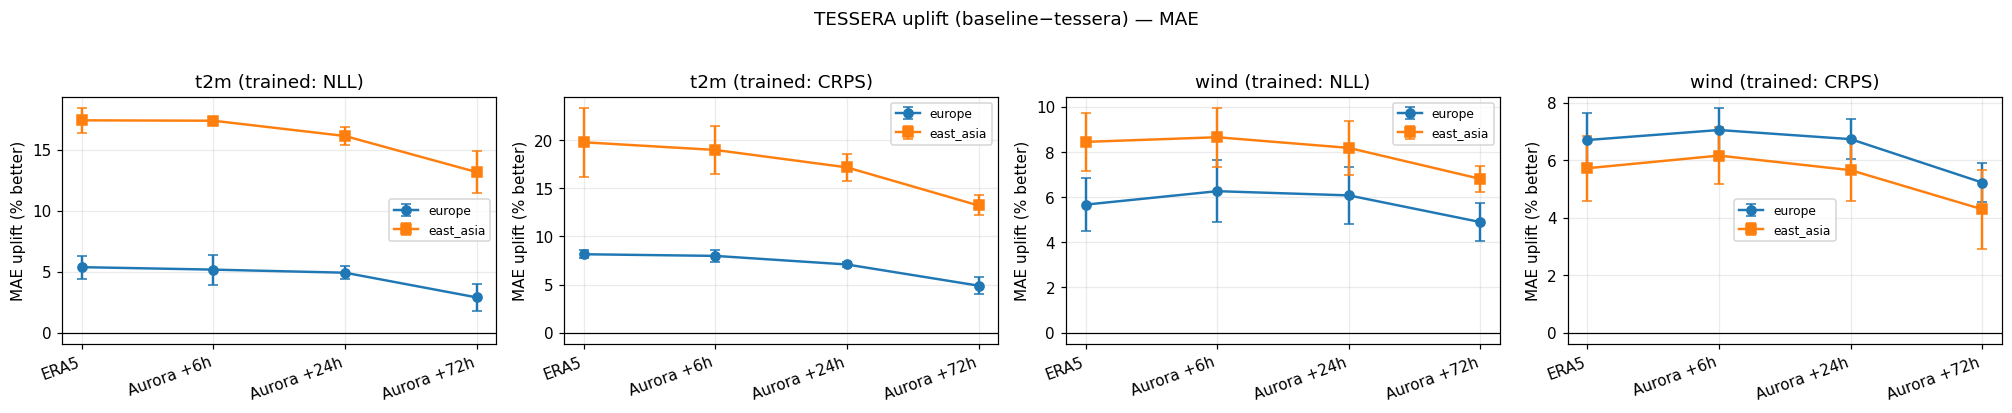

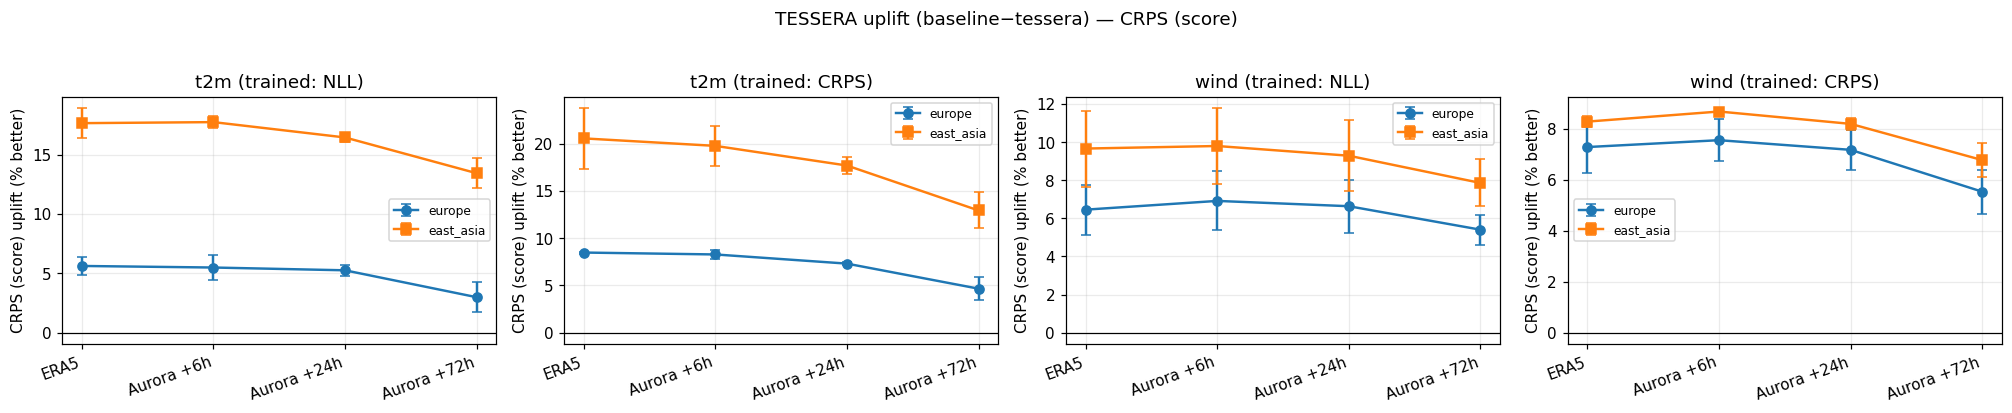


RMSE uplift (% better with TESSERA), seed mean±std:


,region,target,train_loss,eval_label,uplift_pct_mean,uplift_pct_std,n_seeds
0,east_asia,t2m,nll,ERA5,16.106533,1.067038,3
1,east_asia,t2m,nll,Aurora +6h,16.221114,0.491863,3
2,east_asia,t2m,nll,Aurora +24h,15.070190,0.555817,3
3,east_asia,t2m,nll,Aurora +72h,12.678981,1.326758,3
4,east_asia,t2m,crps,ERA5,19.497116,2.895605,3
5,east_asia,t2m,crps,Aurora +6h,18.954388,2.047901,3
6,east_asia,t2m,crps,Aurora +24h,17.397663,1.174782,3
7,east_asia,t2m,crps,Aurora +72h,13.891212,0.614146,3
8,east_asia,wind,nll,ERA5,8.764664,1.690815,3
9,east_asia,wind,nll,Aurora +6h,8.852499,1.706038,3



MAE uplift (% better with TESSERA), seed mean±std:


,region,target,train_loss,eval_label,uplift_pct_mean,uplift_pct_std,n_seeds
0,east_asia,t2m,nll,ERA5,17.440386,1.020893,3
1,east_asia,t2m,nll,Aurora +6h,17.409061,0.225304,3
2,east_asia,t2m,nll,Aurora +24h,16.151655,0.773867,3
3,east_asia,t2m,nll,Aurora +72h,13.186193,1.743865,3
4,east_asia,t2m,crps,ERA5,19.806647,3.575966,3
5,east_asia,t2m,crps,Aurora +6h,19.007836,2.470073,3
6,east_asia,t2m,crps,Aurora +24h,17.194176,1.423450,3
7,east_asia,t2m,crps,Aurora +72h,13.227545,1.041457,3
8,east_asia,wind,nll,ERA5,8.458045,1.276105,3
9,east_asia,wind,nll,Aurora +6h,8.663812,1.300832,3


In [7]:
# === TESSERA uplift ========================================================
def uplift(frame, metric):
    keys = ["region","target","train_loss","seed","eval_label"]
    piv = frame.pivot_table(index=keys, columns="model", values=metric, observed=True)
    if not {"baseline","tessera"}.issubset(piv.columns):
        return pd.DataFrame()
    piv = piv.dropna(subset=["baseline","tessera"])
    piv["uplift_abs"] = piv["baseline"] - piv["tessera"]
    piv["uplift_pct"] = piv["uplift_abs"] / piv["baseline"] * 100
    return piv.reset_index()

def plot_uplift(frame, metric):
    u = uplift(frame, metric)
    if u.empty:
        print(f"(no paired {metric} uplift)"); return
    combos = list(u[["target","train_loss"]].drop_duplicates().itertuples(index=False))
    fig, axes = plt.subplots(1, len(combos), figsize=(4.6*len(combos), 3.6), squeeze=False)
    x = np.arange(len(EVAL_ORDER))
    for ci, (target, tl) in enumerate(combos):
        ax = axes[0][ci]
        for region, mk in zip(REGIONS, ["o","s"]):
            cell = u[(u.target==target)&(u.train_loss==tl)&(u.region==region)]
            a = cell.groupby("eval_label", observed=True)["uplift_pct"].agg(["mean","std"]).reindex(EVAL_ORDER)
            ax.errorbar(x, a["mean"], yerr=a["std"], marker=mk, capsize=3, label=region, lw=1.6)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_xticks(x); ax.set_xticklabels(EVAL_ORDER, rotation=20, ha="right")
        ax.set_title(f"{target} ({trained_lab(tl)})"); ax.set_ylabel(f"{metlab(metric)} uplift (% better)")
        ax.legend(fontsize=8)
    fig.suptitle(f"TESSERA uplift (baseline\u2212tessera) — {metlab(metric)}", y=1.03)
    fig.savefig(OUT_DIR / f"uplift_{metric}.png", bbox_inches="tight"); plt.show()

for metric in ["rmse", "mae", "crps"]:
    plot_uplift(D, metric)

# Table: mean uplift across seeds for RMSE and MAE.
for metric in ["rmse", "mae"]:
    u = uplift(D, metric)
    if u.empty: continue
    tab = (u.groupby(["region","target","train_loss","eval_label"], observed=True)
             .agg(uplift_pct_mean=("uplift_pct","mean"),
                  uplift_pct_std=("uplift_pct","std"),
                  n_seeds=("uplift_pct","count")).reset_index())
    print(f"\n{metlab(metric)} uplift (% better with TESSERA), seed mean\u00b1std:")
    display(tab)

## 6. Probabilistic calibration under the context shift

The predictive distribution was fit on ERA5 context and frozen, so under Aurora
context we expect potential **under-dispersion**. Diagnostics: **PIT χ²** stat /
p-value (higher χ², lower p = worse), and **within-1σ / within-2σ** empirical
coverage vs nominal 68.3% / 95.4%.


T2M calibration (nominal within-1σ=68.3%, within-2σ=95.4%):


region,model,train_loss,eval_label,within_1sigma,within_2sigma,pit_chi2,pit_p,mean_pred_std
east_asia,baseline,nll,ERA5,65.2,92.7,3339.2,0.000,1.543
east_asia,baseline,nll,Aurora +6h,63.6,92.0,5414.1,0.000,1.542
east_asia,baseline,nll,Aurora +24h,61.2,90.4,8205.5,0.000,1.540
east_asia,baseline,nll,Aurora +72h,55.5,86.2,21492.9,0.000,1.541
east_asia,baseline,crps,ERA5,63.6,90.6,6149.1,0.000,1.471
east_asia,baseline,crps,Aurora +6h,62.7,90.2,6182.7,0.000,1.470
east_asia,baseline,crps,Aurora +24h,61.1,88.9,7868.2,0.000,1.470
east_asia,baseline,crps,Aurora +72h,55.8,85.4,17769.3,0.000,1.472
east_asia,tessera,nll,ERA5,67.6,93.6,1348.0,0.000,1.321
east_asia,tessera,nll,Aurora +6h,66.0,93.1,2005.7,0.000,1.320



WIND calibration (nominal within-1σ=68.3%, within-2σ=95.4%):


region,model,train_loss,eval_label,within_1sigma,within_2sigma,pit_chi2,pit_p,mean_pred_std
east_asia,baseline,nll,ERA5,77.5,96.3,5117.7,0.000,1.793
east_asia,baseline,nll,Aurora +6h,77.4,96.2,5213.9,0.000,1.788
east_asia,baseline,nll,Aurora +24h,77.1,96.1,5175.2,0.000,1.789
east_asia,baseline,nll,Aurora +72h,76.1,95.7,5260.5,0.000,1.792
east_asia,baseline,crps,ERA5,71.4,94.0,5177.4,0.000,1.524
east_asia,baseline,crps,Aurora +6h,71.4,93.9,5507.8,0.000,1.522
east_asia,baseline,crps,Aurora +24h,71.1,93.8,5541.4,0.000,1.524
east_asia,baseline,crps,Aurora +72h,70.1,93.2,6238.0,0.000,1.526
east_asia,tessera,nll,ERA5,76.3,96.6,3539.6,0.000,1.617
east_asia,tessera,nll,Aurora +6h,76.2,96.4,3494.7,0.000,1.609


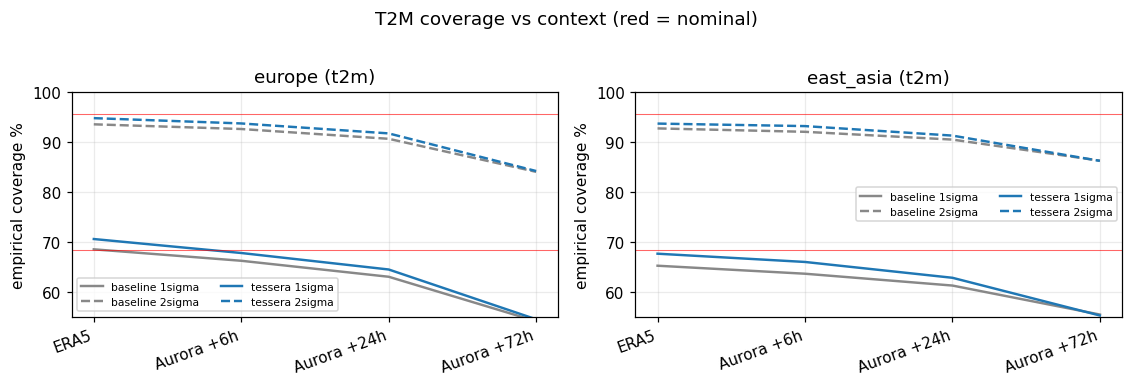

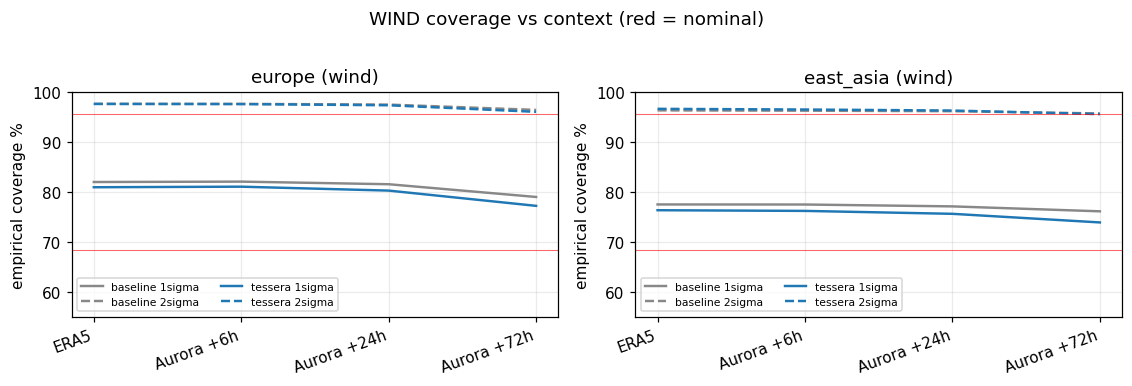

In [16]:
# === Calibration ===========================================================
def calib_table(frame, target):
    sub = frame[frame.target == target]
    if sub.empty: return pd.DataFrame()
    return sub.groupby(["region","model","train_loss","eval_label"], observed=True).agg(
        within_1sigma=("within_1sigma","mean"),
        within_2sigma=("within_2sigma","mean"),
        pit_chi2=("pit_chi2_stat","mean"),
        pit_p=("pit_chi2_pvalue","mean"),
        mean_pred_std=("mean_pred_std","mean")).reset_index()

for target in ["t2m","wind"]:
    t = calib_table(D, target)
    if t.empty: continue
    print(f"\n{target.upper()} calibration (nominal within-1\u03c3=68.3%, within-2\u03c3=95.4%):")
    display(t.style.format({"within_1sigma":"{:.1f}","within_2sigma":"{:.1f}",
                            "pit_chi2":"{:.1f}","pit_p":"{:.3f}","mean_pred_std":"{:.3f}"}).hide(axis="index"))

def plot_coverage(frame, target):
    sub = frame[(frame.target==target) & (frame.train_loss=="nll")]  # ← filter to NLL only
    if sub.empty: return
    fig, axes = plt.subplots(1, len(REGIONS),
                             figsize=(5.2*len(REGIONS), 3.4), squeeze=False)
    x = np.arange(len(EVAL_ORDER))
    for ci, region in enumerate(REGIONS):
        ax = axes[0][ci]
        for model, c in zip(["baseline","tessera"], ["#888888","#1f77b4"]):
            cell = sub[(sub.region==region)&(sub.model==model)]
            for col, ls in [("within_1sigma","-"),("within_2sigma","--")]:
                a = cell.groupby("eval_label", observed=True)[col].mean().reindex(EVAL_ORDER)
                ax.plot(x, a.values, ls, color=c, lw=1.6, label=f"{model} {col.split('_')[1]}")
        for nominal in (68.27, 95.45):
            ax.axhline(nominal, color="red", lw=0.7, alpha=0.6)
        ax.set_xticks(x); ax.set_xticklabels(EVAL_ORDER, rotation=20, ha="right")
        ax.set_title(f"{region} ({target})")  # ← removed trained_lab(tl)
        ax.set_ylim(55, 100)
        ax.set_ylabel("empirical coverage %")
        ax.legend(fontsize=7, ncol=2)
    fig.suptitle(f"{target.upper()} coverage vs context (red = nominal)", y=1.02)
    fig.savefig(OUT_DIR / f"coverage_{target}.png", bbox_inches="tight"); plt.show()

for target in ["t2m","wind"]:
    plot_coverage(D, target)

## 7. Training loss: NLL- vs CRPS-trained models

Same architecture and head, different **training objective**. Does CRPS training
— which directly optimizes the CRPS score — win on the **CRPS score**, and is it
more robust to the context shift? Does it cost **NLL score** / calibration?

Here `train_loss` is the model property; the table values are evaluation scores.


wind — CRPS (score) [evaluation score], by training loss:



wind — NLL (score) [evaluation score], by training loss:



wind — RMSE [evaluation score], by training loss:



wind — MAE [evaluation score], by training loss:


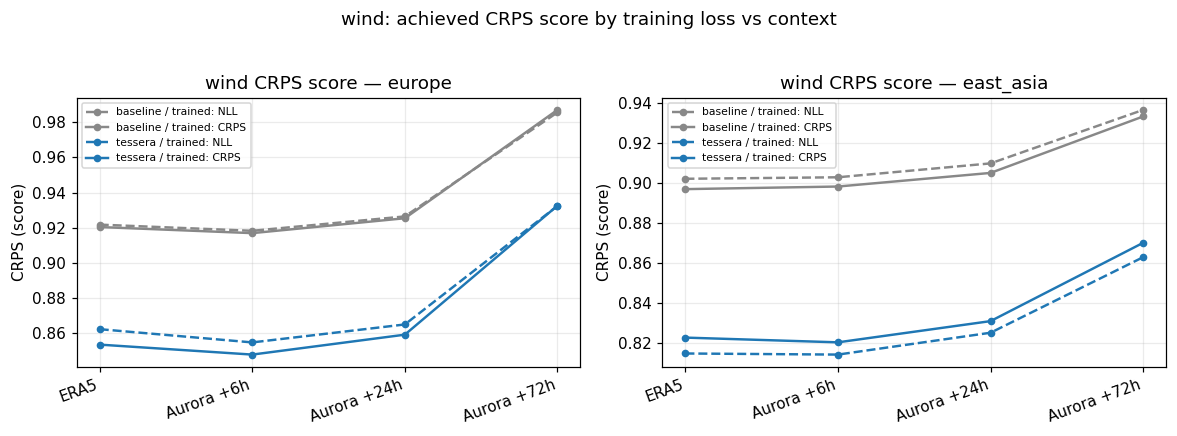


t2m — CRPS (score) [evaluation score], by training loss:



t2m — NLL (score) [evaluation score], by training loss:



t2m — RMSE [evaluation score], by training loss:



t2m — MAE [evaluation score], by training loss:


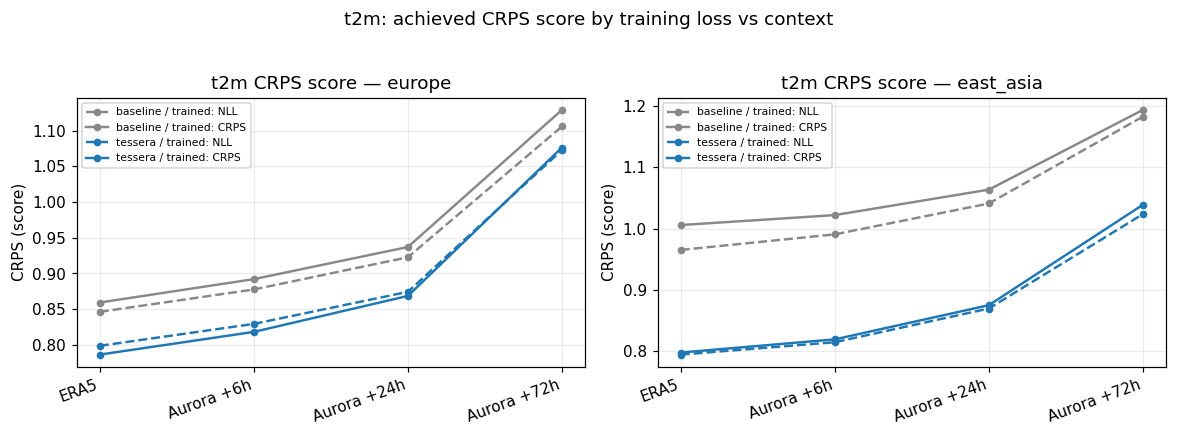

In [9]:
# === NLL- vs CRPS-trained ==================================================
def loss_compare(frame, target):
    sub = frame[frame.target == target]
    tl_present = set(sub["train_loss"])
    if not {"nll","crps"}.issubset(tl_present):
        print(f"({target}: need both NLL- and CRPS-trained models present; "
              f"have {sorted(map(str, tl_present))})")
        return
    for metric in ["crps","nll","rmse","mae"]:
        a = (sub.groupby(["region","model","train_loss","eval_label"], observed=True)[metric]
                  .mean().reset_index())
        p = a.pivot_table(index=["region","model","eval_label"], columns="train_loss",
                          values=metric, observed=False)
        if {"nll","crps"}.issubset(p.columns):
            p[f"(trained CRPS)\u2212(trained NLL)"] = p["crps"] - p["nll"]
        p.columns = [f"trained:{c.upper()}" if c in ("nll","crps") else c for c in p.columns]
        print(f"\n{target} — {metlab(metric)} [evaluation score], by training loss:")
        display(p.reindex(EVAL_ORDER, level="eval_label").style.format("{:.4f}"))

    # Plot: achieved CRPS score, NLL-trained vs CRPS-trained, vs lead.
    fig, axes = plt.subplots(1, len(REGIONS), figsize=(5.4*len(REGIONS), 3.8), squeeze=False)
    x = np.arange(len(EVAL_ORDER))
    for ci, region in enumerate(REGIONS):
        ax = axes[0][ci]
        for model, c in zip(["baseline","tessera"], ["#888888","#1f77b4"]):
            for tl, ls in zip(["nll","crps"], ["--","-"]):
                cell = sub[(sub.region==region)&(sub.model==model)&(sub.train_loss==tl)]
                a = cell.groupby("eval_label", observed=True)["crps"].mean().reindex(EVAL_ORDER)
                if a.notna().sum()==0: continue
                ax.plot(x, a.values, ls, color=c, marker="o", ms=4, lw=1.6,
                        label=f"{model} / {trained_lab(tl)}")
        ax.set_xticks(x); ax.set_xticklabels(EVAL_ORDER, rotation=20, ha="right")
        ax.set_title(f"{target} CRPS score — {region}"); ax.set_ylabel("CRPS (score)")
        ax.legend(fontsize=7)
    fig.suptitle(f"{target}: achieved CRPS score by training loss vs context", y=1.03)
    fig.savefig(OUT_DIR / f"trainloss_compare_{target}.png", bbox_inches="tight"); plt.show()

for target in ["wind", "t2m"]:
    loss_compare(D, target)

## 8. Seasonal breakdown

Seasonal MAE (point estimate = predictive mean). Does the Aurora-context penalty
concentrate in particular seasons? Shown for the TESSERA model.

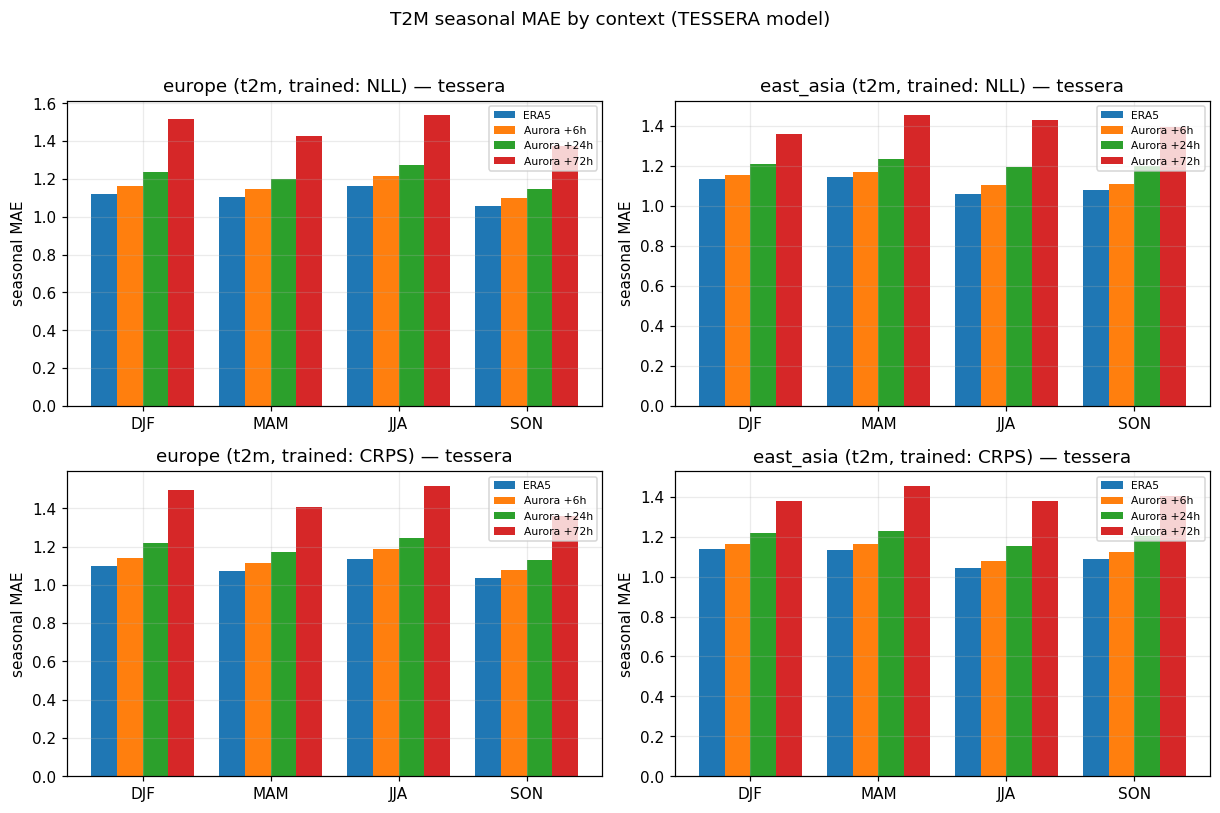

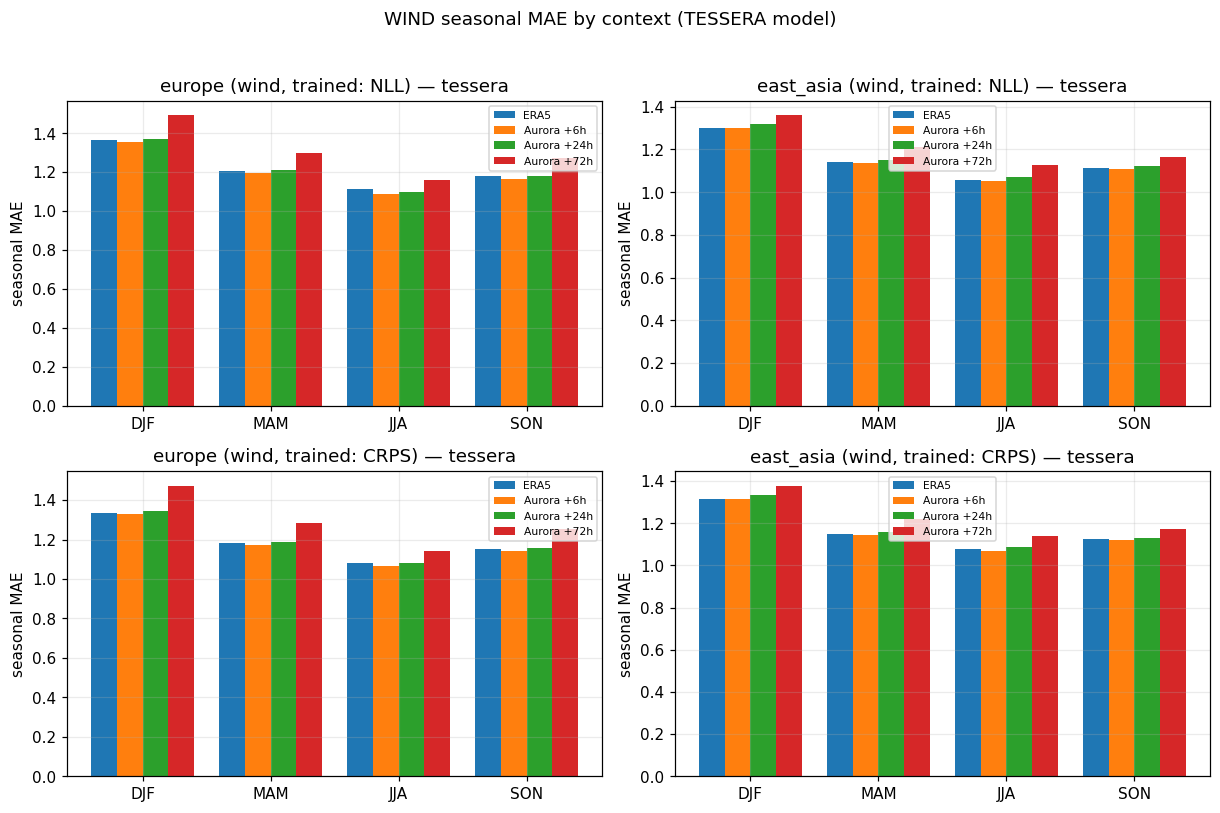

In [10]:
# === Seasonal MAE ==========================================================
seas_cols = [f"seasonal_mae_{s}" for s in SEASONS]
def plot_seasonal(frame, target):
    sub = frame[frame.target == target]
    if sub.empty or sub[seas_cols].notna().sum().sum() == 0:
        print(f"(no seasonal data for {target})"); return
    tlosses = [t for t in ["nll","crps"] if t in set(sub["train_loss"])]
    fig, axes = plt.subplots(len(tlosses), len(REGIONS),
                             figsize=(5.6*len(REGIONS), 3.6*len(tlosses)), squeeze=False)
    xs = np.arange(len(SEASONS)); w = 0.2
    for ri, tl in enumerate(tlosses):
        for ci, region in enumerate(REGIONS):
            ax = axes[ri][ci]
            cell = sub[(sub.region==region)&(sub.train_loss==tl)&(sub.model=="tessera")]
            for k, lab in enumerate(EVAL_ORDER):
                a = cell[cell.eval_label==lab][seas_cols].mean().values
                ax.bar(xs + (k-1.5)*w, a, width=w, label=lab)
            ax.set_xticks(xs); ax.set_xticklabels(SEASONS)
            ax.set_title(f"{region} ({target}, {trained_lab(tl)}) — tessera"); ax.set_ylabel("seasonal MAE")
            ax.legend(fontsize=7)
    fig.suptitle(f"{target.upper()} seasonal MAE by context (TESSERA model)", y=1.02)
    fig.savefig(OUT_DIR / f"seasonal_{target}.png", bbox_inches="tight"); plt.show()

for target in ["t2m","wind"]:
    plot_seasonal(D, target)

## 9. Per-station spatial analysis (focus config)

Loads `test_station_errors.npz`. Set the config via `FOCUS` (`config=None` picks
the first config matching the target / model / training loss; `FOCUS["loss"]` is
the model's *training* loss). Maps show per-station MAE for the ERA5 anchor vs
Aurora +72h and the **degradation map**, plus the MAE distribution and whether
degradation tracks **elevation / sub-grid elevation**.

Focus: europe t2m_snap_vae_lat16_concat_with_elev_no_static_wd seed42 var t2m


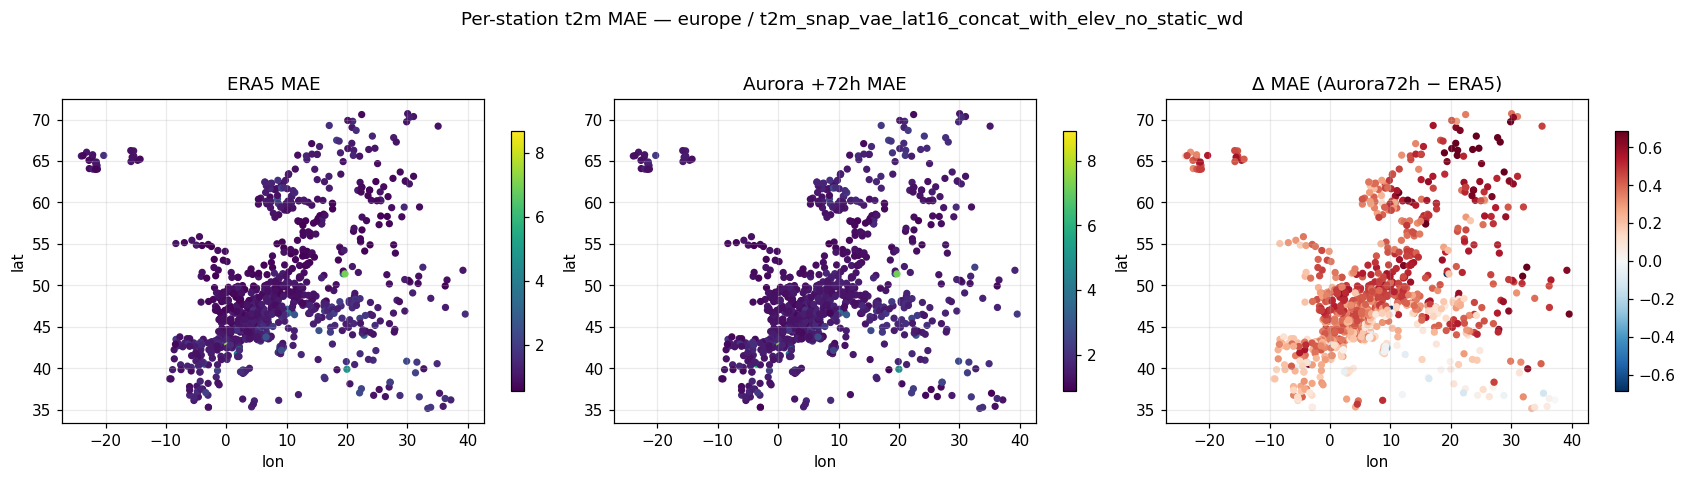

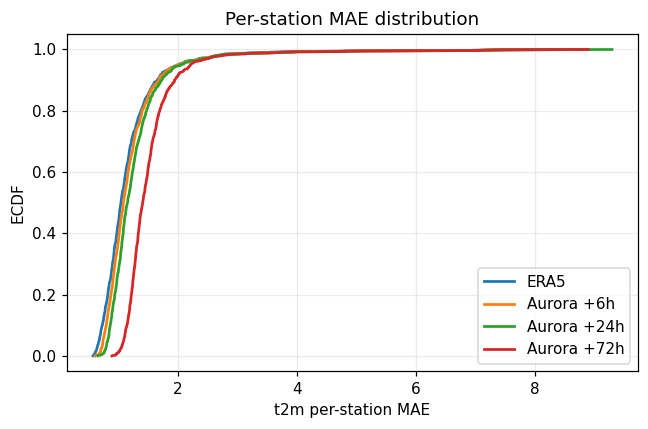

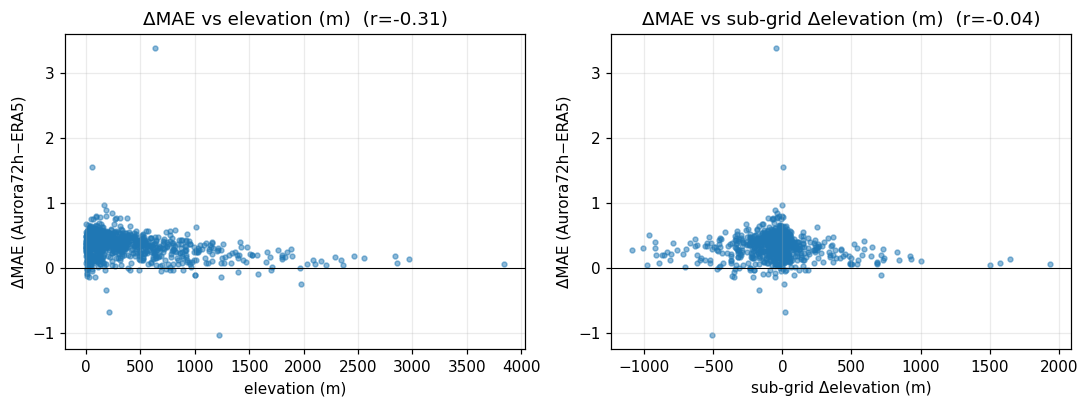

In [11]:
# === Per-station ===========================================================
# FOCUS["loss"] is the model's TRAINING loss; config=None -> first config that
# matches target/model/loss.
FOCUS = dict(region="europe", config=None, target="t2m", model="tessera", loss="nll", seed=42)

def focus_config_name():
    if FOCUS["config"]:
        return FOCUS["config"]
    cand = [c for c in df["config"].unique()
            if parse_config(c)["target"]==FOCUS["target"]
            and parse_config(c)["model"]==FOCUS["model"]
            and parse_config(c)["train_loss"]==FOCUS["loss"]]
    return cand[0] if cand else None

def load_station_npz(region, config, seed, eval_key):
    f = RESULTS_ROOT / region / f"{config}_seed{seed}" / eval_key / "test_station_errors.npz"
    if not f.exists(): return None
    return dict(np.load(f, allow_pickle=True))

cfg = focus_config_name()
var = FOCUS["target"]
print("Focus:", FOCUS["region"], cfg, f"seed{FOCUS['seed']}", "var", var)

st = {k: load_station_npz(FOCUS["region"], cfg, FOCUS["seed"], k) for k in EVAL_SOURCES}
st = {k: v for k, v in st.items() if v is not None}

if not st or cfg is None:
    print("No per-station npz found for the focus config — adjust FOCUS.")
else:
    ref = st.get("eval_era5") or next(iter(st.values()))
    lats, lons, elev = ref["station_lats"], ref["station_lons"], ref["station_elevs"]
    delev = ref.get("station_delta_elevs", np.full_like(elev, np.nan))
    cnt = ref[f"{var}_station_count"]; valid = cnt > 0
    def mae_of(key):
        d = st.get(key); return d[f"{var}_station_mae"] if d is not None else None

    a0 = mae_of("eval_era5"); a72 = mae_of("eval_aurora_lead72h")
    panels = [("ERA5 MAE", a0, "viridis"), ("Aurora +72h MAE", a72, "viridis")]
    if a0 is not None and a72 is not None:
        panels.append(("\u0394 MAE (Aurora72h \u2212 ERA5)", a72 - a0, "RdBu_r"))
    fig, axes = plt.subplots(1, len(panels), figsize=(5.2*len(panels), 4.2), squeeze=False)
    for ax, (title, vals, cmap) in zip(axes[0], panels):
        if vals is None: continue
        vlim = np.nanpercentile(np.abs(vals[valid]), 98) if "\u0394" in title else None
        sc = ax.scatter(lons[valid], lats[valid], c=vals[valid], s=14, cmap=cmap,
                        vmin=(-vlim if vlim else None), vmax=(vlim if vlim else None))
        plt.colorbar(sc, ax=ax, shrink=0.8); ax.set_title(title)
        ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.suptitle(f"Per-station {var} MAE — {FOCUS['region']} / {cfg}", y=1.03)
    fig.savefig(OUT_DIR / "station_maps.png", bbox_inches="tight"); plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    for key, (lab, _) in EVAL_SOURCES.items():
        v = mae_of(key)
        if v is None: continue
        vv = np.sort(v[valid]); ax.plot(vv, np.linspace(0,1,len(vv)), label=lab, lw=1.8)
    ax.set_xlabel(f"{var} per-station MAE"); ax.set_ylabel("ECDF")
    ax.legend(); ax.set_title("Per-station MAE distribution")
    fig.savefig(OUT_DIR / "station_mae_ecdf.png", bbox_inches="tight"); plt.show()

    if a0 is not None and a72 is not None:
        dmae = (a72 - a0)[valid]
        fig, axx = plt.subplots(1, 2, figsize=(10, 3.8))
        for ax, xvar, name in [(axx[0], elev[valid], "elevation (m)"),
                               (axx[1], delev[valid], "sub-grid \u0394elevation (m)")]:
            if np.all(np.isnan(xvar)): continue
            ax.scatter(xvar, dmae, s=10, alpha=0.5)
            good = np.isfinite(xvar) & np.isfinite(dmae)
            if good.sum() > 2:
                r = np.corrcoef(xvar[good], dmae[good])[0,1]
                ax.set_title(f"\u0394MAE vs {name}  (r={r:.2f})")
            ax.set_xlabel(name); ax.set_ylabel("\u0394MAE (Aurora72h\u2212ERA5)"); ax.axhline(0, color="k", lw=0.7)
        fig.savefig(OUT_DIR / "station_degradation_vs_terrain.png", bbox_inches="tight"); plt.show()

## 10. Per-observation diagnostics (PIT, predicted-vs-observed, dispersion)

Loads `test_predictions.npz` for the same FOCUS config. We recompute
the predictive CDF/mean self-contained — Gaussian for t2m, Truncated-Normal on
[0, ∞) for wind — and look at PIT histograms (flat = calibrated), predicted-vs-
observed, and predicted σ vs realized error (the under-dispersion signature when
a frozen spread meets a harder context).

Focus: europe t2m_snap_vae_lat16_concat_with_elev_no_static_wd seed42 (var=t2m, head=gaussian)


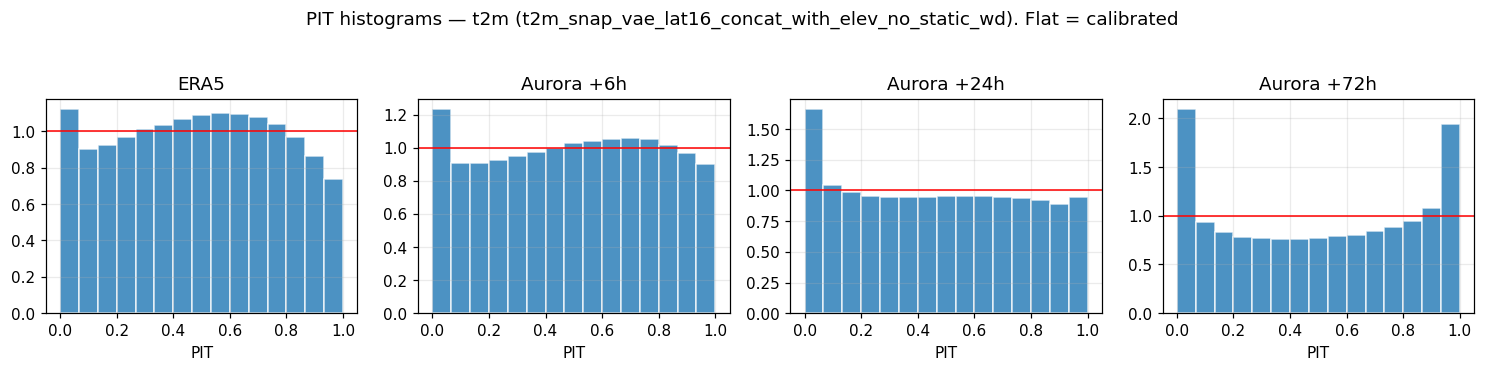

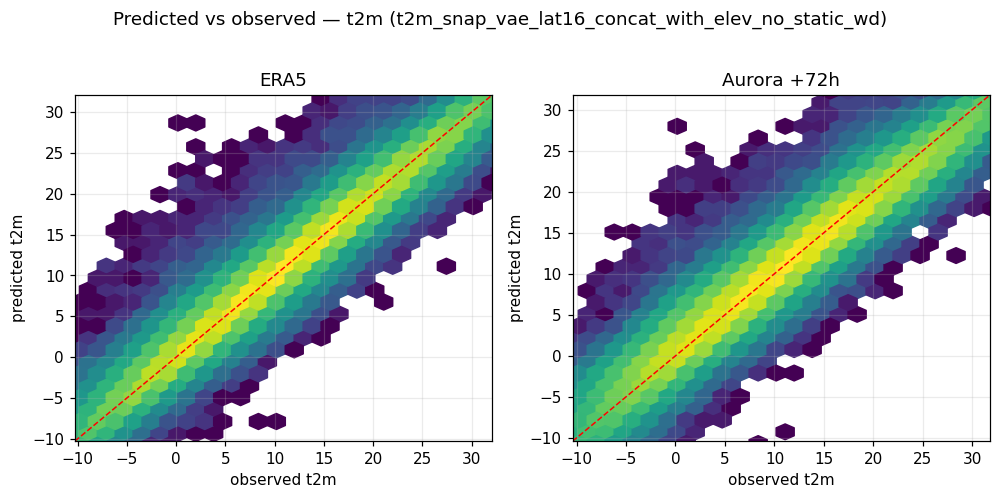

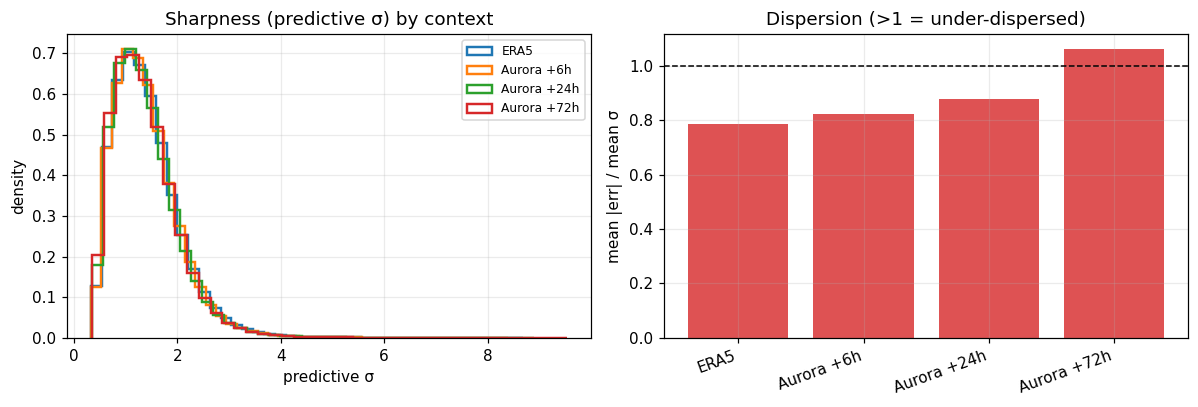

Dispersion summary (focus config):


,mean|err|,mean σ,ratio |err|/σ
context,,,
ERA5,1.110400,1.413246,0.785709
Aurora +6h,1.153400,1.400749,0.823417
Aurora +24h,1.218334,1.385675,0.879235
Aurora +72h,1.466835,1.380432,1.062591


In [12]:
# === Per-observation =======================================================
def predictive(distribution, mu, log_var):
    """(sigma, point_mean, cdf_fn) self-contained, matching evaluate.py clamp."""
    sigma = np.exp(0.5 * np.clip(log_var, -10.0, 10.0))
    if distribution == "gaussian":
        return sigma, mu, (lambda y: stats.norm.cdf(y, loc=mu, scale=sigma))
    if distribution == "truncated_normal":          # lower truncation at 0 (wind >= 0)
        a = (0.0 - mu) / sigma
        mean = stats.truncnorm.mean(a, np.inf, loc=mu, scale=sigma)
        return sigma, mean, (lambda y: stats.truncnorm.cdf(y, a, np.inf, loc=mu, scale=sigma))
    raise ValueError(distribution)

def load_pred_npz(region, config, seed, eval_key):
    f = RESULTS_ROOT / region / f"{config}_seed{seed}" / eval_key / "test_predictions.npz"
    if not f.exists(): return None
    return dict(np.load(f, allow_pickle=True))

dist = "gaussian" if var == "t2m" else "truncated_normal"
preds = {k: load_pred_npz(FOCUS["region"], cfg, FOCUS["seed"], k) for k in EVAL_SOURCES}
preds = {k: v for k, v in preds.items() if v is not None}

if not preds or cfg is None:
    print("No per-observation npz for the focus config — adjust FOCUS.")
else:
    print("Focus:", FOCUS["region"], cfg, f"seed{FOCUS['seed']}", f"(var={var}, head={dist})")

    fig, axes = plt.subplots(1, len(preds), figsize=(3.4*len(preds), 3.2), squeeze=False)
    for ax, (key, d) in zip(axes[0], preds.items()):
        mu = d[f"{var}_param_mu"]; lv = d[f"{var}_param_log_var"]; y = d[f"{var}_targets"]
        _, _, cdf = predictive(dist, mu, lv)
        pit = cdf(y); pit = pit[np.isfinite(pit)]
        ax.hist(pit, bins=15, range=(0,1), density=True, color="#1f77b4", alpha=0.8, edgecolor="white")
        ax.axhline(1.0, color="red", lw=1)
        ax.set_title(EVAL_SOURCES[key][0]); ax.set_xlabel("PIT"); ax.set_ylim(0, None)
    fig.suptitle(f"PIT histograms — {var} ({cfg}). Flat = calibrated", y=1.04)
    fig.savefig(OUT_DIR / "pit_histograms.png", bbox_inches="tight"); plt.show()

    pairs = [(k,l) for k,l in [("eval_era5","ERA5"),("eval_aurora_lead72h","Aurora +72h")] if k in preds]
    if pairs:
        fig, axes = plt.subplots(1, len(pairs), figsize=(4.6*len(pairs), 4.4), squeeze=False)
        for ax, (key, lab) in zip(axes[0], pairs):
            d = preds[key]; _, mean, _ = predictive(dist, d[f"{var}_param_mu"], d[f"{var}_param_log_var"])
            y = d[f"{var}_targets"]
            ax.hexbin(y, mean, gridsize=45, mincnt=1, cmap="viridis", bins="log")
            lo, hi = np.nanpercentile(np.concatenate([y, mean]), [1, 99])
            ax.plot([lo,hi],[lo,hi],"r--",lw=1); ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
            ax.set_xlabel(f"observed {var}"); ax.set_ylabel(f"predicted {var}"); ax.set_title(lab)
        fig.suptitle(f"Predicted vs observed — {var} ({cfg})", y=1.02)
        fig.savefig(OUT_DIR / "pred_vs_obs.png", bbox_inches="tight"); plt.show()

    fig, axx = plt.subplots(1, 2, figsize=(11, 3.8))
    rows_disp = []
    for key, d in preds.items():
        sigma, mean, _ = predictive(dist, d[f"{var}_param_mu"], d[f"{var}_param_log_var"])
        axx[0].hist(sigma, bins=40, histtype="step", density=True, lw=1.6, label=EVAL_SOURCES[key][0])
        err = np.abs(mean - d[f"{var}_targets"])
        rows_disp.append((EVAL_SOURCES[key][0], np.mean(err), np.mean(sigma), np.mean(err)/np.mean(sigma)))
    axx[0].set_xlabel("predictive \u03c3"); axx[0].set_ylabel("density"); axx[0].legend(fontsize=8)
    axx[0].set_title("Sharpness (predictive \u03c3) by context")
    dd = pd.DataFrame(rows_disp, columns=["context","mean|err|","mean \u03c3","ratio |err|/\u03c3"]) \
            .set_index("context").reindex(EVAL_ORDER).dropna(how="all")
    axx[1].bar(np.arange(len(dd)), dd["ratio |err|/\u03c3"].values, color="#d62728", alpha=0.8)
    axx[1].axhline(1.0, color="k", lw=1, ls="--")
    axx[1].set_xticks(np.arange(len(dd))); axx[1].set_xticklabels(dd.index, rotation=20, ha="right")
    axx[1].set_ylabel("mean |err| / mean \u03c3"); axx[1].set_title("Dispersion (>1 = under-dispersed)")
    fig.savefig(OUT_DIR / "dispersion.png", bbox_inches="tight"); plt.show()
    print("Dispersion summary (focus config):"); display(dd)

## 11. Publication summary tables + CSV export

Compact `mean ± std` pivots (rows = target / model / training-loss; columns =
region × context source) for RMSE, MAE, and the CRPS score, plus a dump of the
full tidy table and the headline pivots to `aurora_zeroshot_analysis_outputs/`.

In [13]:
# === Summary tables + export ===============================================
def publication_table(frame, metric):
    a = agg(frame, metric)
    a["cell"] = [fmt_ms(m, s) for m, s in zip(a["mean"], a["std"])]
    a["col"] = a["region"] + " / " + a["eval_label"].astype(str)
    col_order = [f"{r} / {e}" for r in REGIONS for e in EVAL_ORDER]
    p = a.pivot_table(index=["target","model","train_loss"], columns="col",
                      values="cell", aggfunc="first", observed=False)
    return p.reindex(columns=[c for c in col_order if c in p.columns])

for metric in ["rmse","mae","crps"]:
    print(f"\n{'='*82}\nPUBLICATION TABLE — {metlab(metric)} [evaluation score] (mean\u00b1std over seeds)\n{'='*82}")
    pt = publication_table(D, metric)
    display(pt)
    pt.to_csv(OUT_DIR / f"summary_{metric}.csv")

df.to_csv(OUT_DIR / "all_results_tidy.csv", index=False)
print("\nWrote CSVs:", sorted(p.name for p in OUT_DIR.glob('*.csv')))
print("Figures:", sorted(p.name for p in OUT_DIR.glob('*.png')))


PUBLICATION TABLE — RMSE [evaluation score] (mean±std over seeds)


col                        europe / ERA5 europe / Aurora +6h europe / Aurora +24h europe / Aurora +72h east_asia / ERA5 east_asia / Aurora +6h east_asia / Aurora +24h  \
target model    train_loss                                                                                                                                               
t2m    baseline nll          1.680±0.010         1.724±0.010          1.789±0.012          2.050±0.008      1.839±0.025            1.875±0.016             1.952±0.005   
                crps         1.710±0.003         1.753±0.005          1.815±0.003          2.072±0.008      1.915±0.071            1.936±0.054             2.000±0.040   
       tessera  nll          1.597±0.013         1.640±0.014          1.709±0.015          1.993±0.014      1.543±0.002            1.571±0.009             1.658±0.014   
                crps         1.569±0.004         1.611±0.004          1.683±0.002          1.974±0.007      1.540±0.003            1.569±0.004             1.652±0.010   
wind   baseline nll          1.882±0.029         1.877±0.030          1.890±0.028          2.001±0.022      1.746±0.025            1.748±0.028             1.761±0.025   
                crps         1.868±0.009         1.862±0.010          1.875±0.009          1.989±0.010      1.737±0.009            1.740±0.010             1.751±0.009   
       tessera  nll          1.756±0.009         1.743±0.011          1.760±0.010          1.888±0.006      1.593±0.007            1.593±0.004             1.613±0.006   
                crps         1.732±0.008         1.723±0.004          1.742±0.004          1.881±0.004      1.607±0.004            1.603±0.004             1.622±0.005   

col                        east_asia / Aurora +72h  
target model    train_loss                          
t2m    baseline nll                    2.167±0.015  
                crps                   2.195±0.009  
       tessera  nll                    1.892±0.026  
                crps                   1.890±0.020  
wind   baseline nll                    1.815±0.013  
                crps                   1.806±0.006  
       tessera  nll                    1.686±0.009  
                crps                   1.699±0.005


PUBLICATION TABLE — MAE [evaluation score] (mean±std over seeds)


col                        europe / ERA5 europe / Aurora +6h europe / Aurora +24h europe / Aurora +72h east_asia / ERA5 east_asia / Aurora +6h east_asia / Aurora +24h  \
target model    train_loss                                                                                                                                               
t2m    baseline nll          1.174±0.010         1.219±0.009          1.277±0.011          1.509±0.007      1.340±0.023            1.376±0.017             1.443±0.011   
                crps         1.183±0.005         1.228±0.006          1.284±0.004          1.520±0.009      1.374±0.055            1.398±0.039             1.451±0.025   
       tessera  nll          1.111±0.011         1.156±0.012          1.214±0.012          1.465±0.013      1.106±0.006            1.136±0.011             1.210±0.016   
                crps         1.087±0.000         1.130±0.002          1.193±0.001          1.445±0.006      1.101±0.006            1.131±0.004             1.201±0.005   
wind   baseline nll          1.296±0.023         1.288±0.023          1.301±0.023          1.381±0.018      1.264±0.004            1.264±0.002             1.274±0.005   
                crps         1.282±0.003         1.274±0.003          1.287±0.003          1.367±0.003      1.243±0.003            1.244±0.001             1.253±0.003   
       tessera  nll          1.222±0.007         1.207±0.005          1.222±0.005          1.313±0.006      1.158±0.020            1.155±0.019             1.170±0.019   
                crps         1.196±0.014         1.185±0.011          1.200±0.010          1.296±0.011      1.172±0.012            1.167±0.012             1.182±0.013   

col                        east_asia / Aurora +72h  
target model    train_loss                          
t2m    baseline nll                    1.623±0.024  
                crps                   1.618±0.007  
       tessera  nll                    1.409±0.026  
                crps                   1.404±0.015  
wind   baseline nll                    1.310±0.014  
                crps                   1.289±0.010  
       tessera  nll                    1.221±0.021  
                crps                   1.234±0.013


PUBLICATION TABLE — CRPS (score) [evaluation score] (mean±std over seeds)


col                        europe / ERA5 europe / Aurora +6h europe / Aurora +24h europe / Aurora +72h east_asia / ERA5 east_asia / Aurora +6h east_asia / Aurora +24h  \
target model    train_loss                                                                                                                                               
t2m    baseline nll          0.846±0.007         0.878±0.006          0.923±0.007          1.106±0.006      0.965±0.018            0.991±0.013             1.041±0.008   
                crps         0.859±0.002         0.892±0.005          0.937±0.004          1.129±0.015      1.006±0.039            1.022±0.027             1.064±0.016   
       tessera  nll          0.799±0.007         0.829±0.009          0.874±0.009          1.073±0.008      0.795±0.002            0.815±0.007             0.870±0.010   
                crps         0.786±0.002         0.818±0.003          0.869±0.003          1.076±0.008      0.798±0.002            0.820±0.002             0.875±0.006   
wind   baseline nll          0.922±0.013         0.918±0.013          0.926±0.012          0.986±0.008      0.902±0.012            0.903±0.014             0.910±0.012   
                crps         0.920±0.008         0.917±0.008          0.925±0.008          0.987±0.011      0.897±0.003            0.898±0.004             0.905±0.004   
       tessera  nll          0.862±0.001         0.855±0.003          0.865±0.002          0.932±0.001      0.815±0.007            0.814±0.006             0.825±0.006   
                crps         0.853±0.003         0.848±0.000          0.859±0.001          0.932±0.002      0.823±0.004            0.820±0.004             0.831±0.004   

col                        east_asia / Aurora +72h  
target model    train_loss                          
t2m    baseline nll                    1.183±0.016  
                crps                   1.194±0.014  
       tessera  nll                    1.024±0.021  
                crps                   1.039±0.015  
wind   baseline nll                    0.936±0.005  
                crps                   0.933±0.007  
       tessera  nll                    0.863±0.007  
                crps                   0.870±0.004


Wrote CSVs: ['all_results_tidy.csv', 'summary_crps.csv', 'summary_mae.csv', 'summary_rmse.csv']
Figures: ['coverage_t2m.png', 'coverage_wind.png', 'degradation_t2m_crps.png', 'degradation_t2m_mae.png', 'degradation_t2m_rmse.png', 'degradation_wind_crps.png', 'degradation_wind_mae.png', 'degradation_wind_rmse.png', 'dispersion.png', 'pit_histograms.png', 'pred_vs_obs.png', 'seasonal_t2m.png', 'seasonal_wind.png', 'station_degradation_vs_terrain.png', 'station_mae_ecdf.png', 'station_maps.png', 'trainloss_compare_t2m.png', 'trainloss_compare_wind.png', 'uplift_crps.png', 'uplift_mae.png', 'uplift_rmse.png', 'wind_nll_vs_crps.png']


### Caveats

- **n = 3 seeds.** Bands are ±1 std over three seeds — indicative, not a
  significance test.
- **NLL / CRPS — loss vs score.** "trained: NLL/CRPS" is the model's training
  objective (`train_loss`); "NLL (score)" / "CRPS (score)" are evaluation metrics
  computed for every model. t2m currently has only NLL-trained models; once a
  CRPS-trained t2m set is added it appears automatically in every section.
- **Zero-shot by construction.** The predictive spread was fit on ERA5 context
  and frozen; under-dispersion under Aurora context (§6, §10) reflects the
  distribution shift, not a training failure — it quantifies the cost of using a
  forecast as context without re-calibration.
- **Point estimate.** For the Truncated-Normal (wind) head the point estimate is
  the truncated mean, recomputed self-contained in §10 to match `evaluate.py`.
- Edit `RESULTS_ROOT` (cell 2) and `FOCUS` (§9) to retarget; re-run top-to-bottom.